# Fair-pay checker: does a worker earn above the median for their job and state?

**AI for Good - Hackathon 5 "Model Showdown" · SDG 8.5 (equal pay for work of equal value)**

A worker-advice centre enters a member's job profile (occupation, industry, state, age, education, hours, weeks, type of employer).
The model estimates how likely it is that *people with this profile* earn **above the median hourly wage of their occupation in their state**.
If that probability is high but the member actually earns *below* the median, the centre has a reason to look closer: the member may be underpaid
and could use help to negotiate.

Data: US Census Bureau, American Community Survey (ACS) 2024 1-year Public Use Microdata Sample (PUMS), all 50 states + DC.
Models: a dummy baseline, KNN, logistic regression and histogram gradient boosting (scikit-learn).

**Runtime:** the first run downloads a 575 MB file from census.gov (a few minutes, sometimes slower, because census.gov limits download speed).
The file is cached in `data/`, so later runs skip the download. Tuning, the under/overfitting analysis and evaluation take about 20 minutes on a 12-core laptop and roughly 45–70 minutes on a standard Colab CPU (estimate).

In [1]:
import time
import urllib.request
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, confusion_matrix, f1_score, log_loss,
                             precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import (GridSearchCV, GroupShuffleSplit, StratifiedGroupKFold,
                                     cross_validate, learning_curve)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42  # one seed for every split, sample and model, so the numbers are reproducible
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# one colour scheme for all plots: in every train-vs-validation plot, training is blue and dashed, validation/test is orange and solid
TRAIN_C, VAL_C = "#2a78d6", "#eb6834"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": "#e3e3e0",
                     "axes.prop_cycle": plt.cycler(color=["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7"])})
print("python packages:", "pandas", pd.__version__, "| numpy", np.__version__,
      "| scikit-learn", sklearn.__version__, "| matplotlib", plt.matplotlib.__version__)

python packages: pandas 2.3.3 | numpy 2.3.5 | scikit-learn 1.7.2 | matplotlib 3.10.6


## 1. Frame the problem

**Target.** `y = 1` if a worker's hourly wage is **above the median hourly wage of workers in the same detailed occupation in the same state**, else `y = 0`.
The positive class is "above the median".
* *Hourly* wage = yearly wages ÷ (usual hours per week × weeks worked). With yearly wages, "below the median" would mostly mean "works part-time".
* *Within state*: a cashier in Massachusetts is compared with cashiers in Massachusetts, not with cashiers in Mississippi, because prices and pay levels differ a lot between states.
* The medians are computed **on the training set only** (step 4), so the test set does not influence its own labels.

**User and decision.** A worker-advice centre or union confederation that serves members in many sectors. For each member it decides whether to raise a
*"you may be underpaid"* signal and offer help with a pay negotiation. The signal is raised when the model says *people like you are usually above the median*
but the member's own wage is below it. The member's own wage alone is not enough: a 20-year-old without a degree is *expected* to earn below the median,
and that is not a sign of unfair pay. The model adds what is *typical for the profile*.

**Which mistake is worse?** Careful: the signal is not the same as a correct "above" prediction. The workers who get a signal are exactly the model's
**false positives** at the signal threshold: predicted "above" (their profile usually earns more), actually "below". So the classifier's error types do not map
one-to-one onto good and bad signals. What matters for the member is whether a signal is *justified*:
* *Unjustified signal:* the profile looks like it should earn more, but the low wage has a legitimate reason the data cannot see (short tenure, a small employer,
  a job title that hides a junior role). The member is pushed into a failed negotiation or a bad job switch and loses trust in the centre.
* *Missed underpaid worker:* the model's probability for an underpaid member's profile stays below the threshold, so they get no signal and stay underpaid.

Whether a single signal is justified cannot be checked in the data, because the reasons are not in it. What *can* be checked is whether the model's probability
ranks profiles well. A model that ranks badly gives high probabilities to profiles that do not really earn more, which produces unjustified signals and misses at the same time.
We treat the **unjustified signal as the worse mistake**: it costs the member a negotiation, their relationship with the employer and their trust in the centre,
while a missed member can still come to the centre on their own. So the signal is raised only for profiles that are *clearly* above the median (a strict threshold, step 8).

**Main metric: ROC-AUC.** The tool gives a *probability*, and the signal is raised only above a strict threshold (chosen in step 8). So the main question is whether
a higher probability really means "more likely above the median". ROC-AUC measures exactly that: pick one random above-median and one random below-median worker;
how often does the model give the first one the higher probability? 0.5 is a coin flip, 1.0 is perfect. Precision, recall and F1 are reported as well.

*Why not F1?* We first chose F1. But because about half of all workers are above their median (that is what a median does), a lazy rule that says "above" for
**everyone** already gets F1 ≈ 0.66: it finds every positive (recall 100%) and is right half the time (precision 49%). Such a rule is useless to the centre,
since it would tell every member they "should" earn more, but F1 ranked it above our real models. The "always above" rule is kept in the comparison table to show this.
ROC-AUC gives any rule that answers the same for everyone exactly 0.5.

**Size of the problem.** In the 2024 ACS, women working full-time, year-round earned 83% of men's median earnings; within some occupation groups it is 74%
([US Census Bureau, Equal Pay Day 2026](https://www.census.gov/newsroom/stories/equal-pay-day.html)). Part of that gap sits *within* the same occupation,
which is exactly what this tool tries to make visible.

## 2. Get the data and explore it

**Source.** ACS 2024 1-year PUMS, person file for the whole US (`csv_pus.zip`, 575 MB, two CSV files inside), plus the official data dictionary for code labels.
Public domain (a US federal government work). The Census Bureau anonymises the sample before release: it is a subset of responses,
some records are swapped, extreme values are top-coded, and there are no names or addresses.
The zip is too big for the repository, so this cell downloads it and caches it in `data/`.

In [2]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
BASE = "https://www2.census.gov/programs-surveys/acs"
FILES = {
    "csv_pus.zip": f"{BASE}/data/pums/2024/1-Year/csv_pus.zip",
    "PUMS_Data_Dictionary_2024.csv": f"{BASE}/tech_docs/pums/data_dict/PUMS_Data_Dictionary_2024.csv",
}
for name, url in FILES.items():
    path = DATA_DIR / name
    if path.exists():
        print("already downloaded:", path)
        continue
    print("downloading", url, "...")
    start = time.time()
    tmp = path.with_suffix(".part")  # download under a temporary name, so a broken download is never mistaken for a complete file
    urllib.request.urlretrieve(url, tmp)
    tmp.rename(path)
    print(f"  done in {time.time() - start:.0f} s")

already downloaded: data\csv_pus.zip
already downloaded: data\PUMS_Data_Dictionary_2024.csv


We load only the columns we need (the file has 280+ columns). Used as **features**: occupation, industry, age, education, hours, weeks, class of worker.
Used **only to build the target**: wages, the income adjustment factor and state. Used **only for the fairness audit** (never shown to the model): sex,
race, Hispanic origin and citizenship. Household id and person number are used for the group-aware split and the duplicate check.

In [3]:
COLS = ["SERIALNO", "SPORDER", "STATE", "ADJINC", "WAGP", "WKHP", "WKWN", "ESR", "COW",
        "OCCP", "INDP", "AGEP", "SCHL", "SEX", "RAC1P", "HISP", "CIT"]
start = time.time()
with zipfile.ZipFile(DATA_DIR / "csv_pus.zip") as z:
    raw = pd.concat([pd.read_csv(z.open(n), usecols=COLS, dtype={"SERIALNO": str})
                     for n in ("psam_pusa.csv", "psam_pusb.csv")], ignore_index=True)
print(f"loaded {len(raw):,} persons x {raw.shape[1]} columns in {time.time() - start:.0f} s")
raw.head()

loaded 3,422,888 persons x 17 columns in 41 s


,SERIALNO,SPORDER,STATE,ADJINC,AGEP,CIT,COW,SCHL,SEX,WAGP,WKHP,WKWN,ESR,HISP,INDP,OCCP,RAC1P
0,2024GQ0000060,1,1,1015250,59,1,1.0,10.0,1,18500.0,30.0,52.0,6.0,1,9070.0,8300.0,2
1,2024GQ0000094,1,1,1015250,43,1,NaN,17.0,1,0.0,NaN,NaN,6.0,1,NaN,NaN,1
2,2024GQ0000146,1,1,1015250,75,1,NaN,16.0,2,0.0,NaN,NaN,6.0,1,NaN,NaN,2
3,2024GQ0000156,1,1,1015250,22,3,1.0,19.0,2,0.0,NaN,NaN,6.0,1,3365.0,7010.0,6
4,2024GQ0000182,1,1,1015250,51,1,NaN,16.0,1,0.0,NaN,NaN,6.0,1,NaN,NaN,1


**Population filters.** We keep employed wage and salary workers of working age, and record how many rows each filter drops:
* age 18–64 (working age);
* civilian employed now (`ESR` 1 or 2). Armed forces are excluded because military pay follows fixed tables;
* employees (`COW` 1–5). Self-employed and unpaid family workers do not have a wage that can be compared;
* positive wages; more than 4 weeks worked and more than 5 usual hours per week. For very marginal jobs, the hourly wage computed from yearly
  survey answers is unreliable;
* hourly wage at least $2. Anything lower is below every legal US minimum wage (the tipped minimum is $2.13), so it is a reporting error.

`ADJINC` converts the reported wages to 2024 dollars (as stated by the ACS documentation). It has 6 implied decimals, so we divide by 1,000,000.

In [4]:
raw["hourly"] = raw.WAGP * raw.ADJINC / 1e6 / (raw.WKHP * raw.WKWN)  # NaN for people without hours/weeks

FILTERS = [
    ("age 18-64", lambda d: d.AGEP.between(18, 64)),
    ("civilian employed (ESR 1-2)", lambda d: d.ESR.isin([1, 2])),
    ("employee, not self-employed (COW 1-5)", lambda d: d.COW.isin([1, 2, 3, 4, 5])),
    ("wages > 0", lambda d: d.WAGP > 0),
    ("more than 4 weeks worked", lambda d: d.WKWN > 4),
    ("more than 5 usual hours/week", lambda d: d.WKHP > 5),
    ("hourly wage >= $2", lambda d: d.hourly >= 2),
]
workers, log = raw, [("all persons in the file", len(raw), None)]
for reason, rule in FILTERS:
    before = len(workers)
    workers = workers[rule(workers)]
    log.append((reason, len(workers), before - len(workers)))
del raw  # free memory
workers = workers.copy()
pd.DataFrame(log, columns=["filter", "rows left", "rows dropped"])

,filter,rows left,rows dropped
0,all persons in the file,3422888,NaN
1,age 18-64,1976963,1445925.0
2,civilian employed (ESR 1-2),1429593,547370.0
3,"employee, not self-employed (COW 1-5)",1290253,139340.0
4,wages > 0,1290253,0.0
5,more than 4 weeks worked,1279839,10414.0
6,more than 5 usual hours/week,1271489,8350.0
7,hourly wage >= $2,1268428,3061.0


**Readable labels.** The data dictionary gives each occupation and industry code a label such as `MGR-Chief Executives And Legislators`.
The prefix before the dash is the broad group (e.g. MGR = management). We use it as an extra feature (`occ_group`, `ind_group`)
and as the "sector" for the audit. The full names of all group codes are in the table below. The audit columns are recoded into a few readable groups.

In [5]:
dd = pd.read_csv(DATA_DIR / "PUMS_Data_Dictionary_2024.csv", header=None, names=range(7), dtype=str)

def code_labels(var):
    v = dd[(dd[0] == "VAL") & (dd[1] == var) & dd[4].str.isdigit()]
    return dict(zip(v[4].astype(int), v[6]))

OCC_LABEL, IND_LABEL, STATE_LABEL = code_labels("OCCP"), code_labels("INDP"), code_labels("STATE")

workers["OCCP"] = workers.OCCP.astype(int)
workers["INDP"] = workers.INDP.astype(int)
workers["occ_group"] = workers.OCCP.map(OCC_LABEL).str.split("-", n=1).str[0]
workers["ind_group"] = workers.INDP.map(IND_LABEL).str.split("-", n=1).str[0]
assert workers[["occ_group", "ind_group"]].notna().all().all(), "every code should have a label"

# full names of the group codes (Census occupation and industry groups, checked against the labels in the data dictionary)
OCC_GROUP_NAME = {
    "MGR": "Management", "BUS": "Business operations", "FIN": "Financial specialists", "CMM": "Computer and mathematical",
    "ENG": "Architecture and engineering", "SCI": "Life, physical and social science", "CMS": "Community and social service",
    "LGL": "Legal", "EDU": "Education, training and library", "ENT": "Arts, design, entertainment, sports and media",
    "MED": "Healthcare practitioners and technical", "HLS": "Healthcare support", "PRT": "Protective service",
    "EAT": "Food preparation and serving", "CLN": "Building and grounds cleaning and maintenance", "PRS": "Personal care and service",
    "SAL": "Sales", "OFF": "Office and administrative support", "FFF": "Farming, fishing and forestry", "CON": "Construction",
    "EXT": "Extraction (mining, oil and gas)", "RPR": "Installation, maintenance and repair", "PRD": "Production",
    "TRN": "Transportation and material moving",
}
IND_GROUP_NAME = {
    "AGR": "Agriculture, forestry, fishing and hunting", "EXT": "Mining, oil and gas extraction", "UTL": "Utilities",
    "CON": "Construction", "MFG": "Manufacturing", "WHL": "Wholesale trade", "RET": "Retail trade",
    "TRN": "Transportation and warehousing", "INF": "Information (publishing, media, telecom)",
    "FIN": "Finance, insurance and real estate", "PRF": "Professional, scientific, management, administrative and waste services",
    "EDU": "Educational services", "MED": "Health care", "SCA": "Social assistance (incl. child care)",
    "ENT": "Arts, entertainment, recreation, accommodation and food services", "SRV": "Other services (repair, personal care, organisations)",
    "ADM": "Public administration",
}
assert workers.occ_group.isin(OCC_GROUP_NAME).all() and workers.ind_group.isin(IND_GROUP_NAME).all()

# audit-only columns (never used as features)
workers["sex"] = workers.SEX.map({1: "male", 2: "female"})
workers["race_eth"] = np.where(workers.HISP != 1, "Hispanic",
                               workers.RAC1P.map({1: "White", 2: "Black", 6: "Asian"}).fillna("Other/multiple"))
workers["migration"] = workers.CIT.map({1: "born US citizen", 2: "born US citizen", 3: "born US citizen",
                                        4: "naturalised citizen", 5: "non-citizen"})
print(workers.occ_group.nunique(), "occupation groups,", workers.OCCP.nunique(), "detailed occupations,",
      workers.ind_group.nunique(), "industry groups,", workers.STATE.nunique(), "states (incl. DC)")

24 occupation groups, 525 detailed occupations, 17 industry groups, 51 states (incl. DC)


In [6]:
# the group codes used in the rest of the notebook, with the number of workers in each
codes = pd.concat([
    pd.DataFrame({"code": list(OCC_GROUP_NAME), "name": list(OCC_GROUP_NAME.values()), "type": "occupation group"}),
    pd.DataFrame({"code": list(IND_GROUP_NAME), "name": list(IND_GROUP_NAME.values()), "type": "industry group"}),
])
codes["workers"] = [(workers.occ_group if t == "occupation group" else workers.ind_group).eq(c).sum()
                    for c, t in zip(codes.code, codes.type)]
codes.set_index(["type", "code"])

name  workers
type             code                                                            
occupation group MGR                                          Management   151255
                 BUS                                 Business operations    55023
                 FIN                               Financial specialists    28963
                 CMM                           Computer and mathematical    58162
                 ENG                        Architecture and engineering    34168
                 SCI                   Life, physical and social science    17416
                 CMS                        Community and social service    25005
                 LGL                                               Legal    14364
                 EDU                     Education, training and library    94000
                 ENT       Arts, design, entertainment, sports and media    21842
                 MED              Healthcare practitioners and technical    92224
                 HLS                                  Healthcare support    40363
                 PRT                                  Protective service    28715
                 EAT                        Food preparation and serving    60549
                 CLN       Building and grounds cleaning and maintenance    31988
                 PRS                           Personal care and service    22822
                 SAL                                               Sales   100486
                 OFF                   Office and administrative support   138560
                 FFF                       Farming, fishing and forestry     6925
                 CON                                        Construction    48494
                 EXT                    Extraction (mining, oil and gas)     1470
                 RPR                Installation, maintenance and repair    39125
                 PRD                                          Production    67986
                 TRN                  Transportation and material moving    88523
industry group   AGR          Agriculture, forestry, fishing and hunting    12057
                 EXT                      Mining, oil and gas extraction     5299
                 UTL                                           Utilities    13860
                 CON                                        Construction    73224
                 MFG                                       Manufacturing   138126
                 WHL                                     Wholesale trade    24941
                 RET                                        Retail trade   130534
                 TRN                      Transportation and warehousing    57112
                 INF            Information (publishing, media, telecom)    24577
                 FIN                  Finance, insurance and real estate    82670
                 PRF   Professional, scientific, management, administ...   152914
                 EDU                                Educational services   144781
                 MED                                         Health care   161994
                 SCA                Social assistance (incl. child care)    27471
                 ENT   Arts, entertainment, recreation, accommodation...    98800
                 SRV   Other services (repair, personal care, organis...    48115
                 ADM                               Public administration    71953

### Explore

Size, types, missing values, duplicates and impossible values.

In [7]:
NUM = ["AGEP", "SCHL", "WKHP", "WKWN"]         # age, education (ordered code 1-24), usual hours/week, weeks worked
CAT = ["OCCP", "occ_group", "ind_group", "COW"]  # detailed occupation, occupation group, industry group, class of worker
FEATURES = NUM + CAT
AUDIT = ["sex", "race_eth", "migration"]

print(f"{len(workers):,} workers")
print("missing values per column:\n", workers[FEATURES + AUDIT + ["hourly", "STATE"]].isna().sum().to_string())
print("duplicate persons (same household id + person number):", workers.duplicated(["SERIALNO", "SPORDER"]).sum())
print("rows identical on all features:", f"{workers.duplicated(FEATURES).mean():.1%}",
      "(different people who share the same profile, not copied rows)")
workers[NUM + ["hourly"]].describe(percentiles=[0.01, 0.5, 0.99]).round(1)

1,268,428 workers


missing values per column:
 AGEP         0
SCHL         0
WKHP         0
WKWN         0
OCCP         0
occ_group    0
ind_group    0
COW          0
sex          0
race_eth     0
migration    0
hourly       0
STATE        0


duplicate persons (same household id + person number): 0


rows identical on all features: 36.7% (different people who share the same profile, not copied rows)


,AGEP,SCHL,WKHP,WKWN,hourly
count,1268428.0,1268428.0,1268428.0,1268428.0,1268428.0
mean,41.2,18.9,39.5,49.5,36.7
std,13.0,3.4,10.7,8.0,44.6
min,18.0,1.0,6.0,5.0,2.0
1%,18.0,1.0,8.0,10.0,3.4
50%,41.0,20.0,40.0,52.0,26.4
99%,64.0,24.0,72.0,52.0,216.9
max,64.0,24.0,99.0,52.0,10755.3


* No missing values remain after the filters (every employed person answered these questions or the Census Bureau imputed the answer). So the pipeline needs no imputer.
* No person appears twice. Many rows share the same feature *values*, but those are different people with the same profile.
  That is normal for survey data and cannot leak information between train and test.
* Impossible values: age and weeks are within range. Hours are top-coded at 99 ("99 or more"), and wages are top-coded by the Census Bureau.
  This affects only the highest earners, who are above their median either way.
* The hourly wage has a long right tail (the 99th percentile is far above the median), so it is shown on a log scale below.

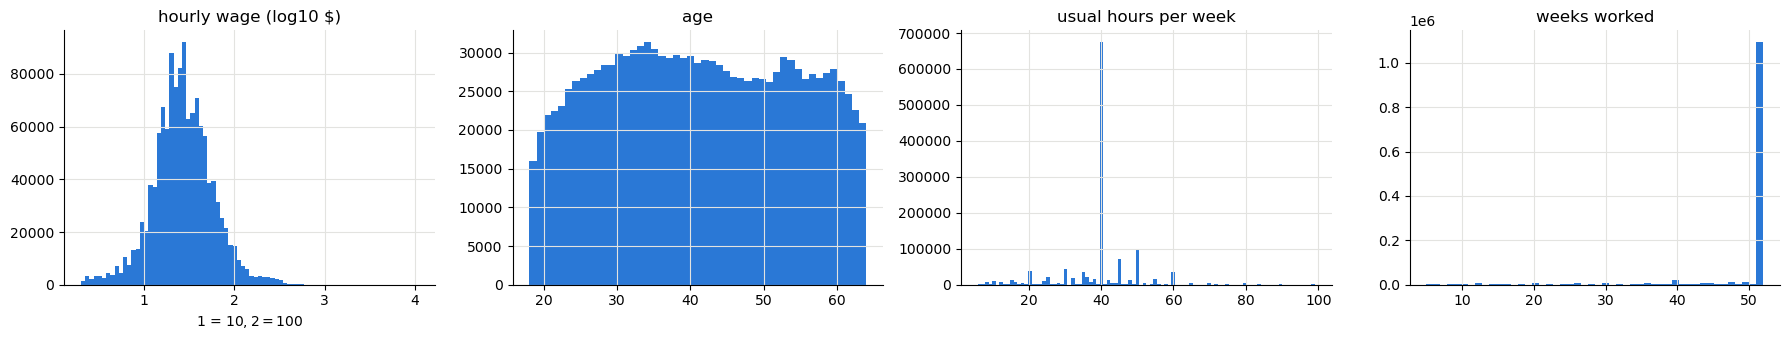

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.5))
axes[0].hist(np.log10(workers.hourly), bins=80)
axes[0].set(title="hourly wage (log10 $)", xlabel="1 = $10, 2 = $100")
axes[1].hist(workers.AGEP, bins=47); axes[1].set(title="age")
axes[2].hist(workers.WKHP, bins=94); axes[2].set(title="usual hours per week")
axes[3].hist(workers.WKWN, bins=48); axes[3].set(title="weeks worked")
plt.tight_layout(); plt.show()

**Leakage check.** Wages (`WAGP`), the hourly wage and every other income column are *outcomes*, so none of them is a feature.
Hours and weeks are used in the hourly-wage formula, but they describe the job and the worker knows them before any pay comparison, so they are allowed as features.
Detailed industry (270 codes) is reduced to its group to keep the number of columns manageable.
**State** is not a feature: the target is already defined *within* each state.

## 3. Split first

We put 20% of the data aside as the test set **before** computing medians, scaling or tuning.
* **Group-aware:** about two thirds of workers share a household with another worker in the sample. Partners and family members are similar (same place, often similar jobs),
  so we split by household (`SERIALNO`). Nobody in the test set has a housemate in the training set.
* **Not stratified on the target:** the target does not exist yet, because its medians are computed on the training part.
  With over a million rows, a random household split gives the same class balance in both parts. We check this below.

In [9]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(workers, groups=workers.SERIALNO))
train_all, test_all = workers.iloc[train_idx], workers.iloc[test_idx]
assert not set(train_all.SERIALNO) & set(test_all.SERIALNO), "a household is in both train and test"
print(f"train: {len(train_all):,} workers | test: {len(test_all):,} workers")

train: 1,014,613 workers | test: 253,815 workers


**Target from training data only.** For each state × occupation cell we compute the median hourly wage on the **training set**.
A cell is used only if it has **at least 30 training workers**; a median of fewer people is too noisy. Workers in smaller cells are **"not covered"**:
the model gives them no prediction at all. The same training medians are used to label the test set.

In [10]:
MIN_CELL = 30
cells = (train_all.groupby(["STATE", "OCCP"]).hourly
         .agg(cell_median="median", cell_n="size").reset_index())
covered_cells = cells[cells.cell_n >= MIN_CELL]

def add_target(d):
    d = d.merge(covered_cells[["STATE", "OCCP", "cell_median"]], on=["STATE", "OCCP"], how="left")
    d["covered"] = d.cell_median.notna()
    d["y"] = (d.hourly > d.cell_median).astype(int)
    return d

train_all, test_all = add_target(train_all), add_target(test_all)
print(f"{len(covered_cells):,} of {len(cells):,} state x occupation cells have >= {MIN_CELL} training workers")
print(f"covered workers: train {train_all.covered.mean():.1%}, test {test_all.covered.mean():.1%}")

# who is NOT covered? (an equity question: the tool cannot help these people)
print("\nshare of training workers NOT covered, per group:")
for col in AUDIT + ["occ_group"]:
    print(" ", (1 - train_all.groupby(col).covered.mean()).round(3).sort_values(ascending=False).head(6).to_dict())
by_state = 1 - train_all.groupby(train_all.STATE.map(STATE_LABEL)).covered.mean()
print("  states with the lowest coverage:", by_state.sort_values(ascending=False).head(5).round(2).to_dict())

6,415 of 23,239 state x occupation cells have >= 30 training workers
covered workers: train 86.0%, test 85.6%

share of training workers NOT covered, per group:
  {'male': 0.151, 'female': 0.129}
  {'Other/multiple': 0.168, 'White': 0.158, 'Black': 0.125, 'Hispanic': 0.093, 'Asian': 0.092}


  {'born US citizen': 0.149, 'non-citizen': 0.094, 'naturalised citizen': 0.091}
  {'EXT': 0.797, 'ENT': 0.431, 'SCI': 0.428, 'PRS': 0.315, 'RPR': 0.281, 'CMS': 0.258}
  states with the lowest coverage: {'Vermont/VT': 0.81, 'Alaska/AK': 0.8, 'Wyoming/WY': 0.77, 'North Dakota/ND': 0.72, 'Delaware/DE': 0.69}


In [11]:
train = train_all[train_all.covered].reset_index(drop=True)
test = test_all[test_all.covered].reset_index(drop=True)
print(f"class balance (share above median): train {train.y.mean():.3f} | test {test.y.mean():.3f}")
print("(slightly below 0.5 because workers paid exactly the median count as 'not above')\n")
print("share above the median per group (training set):")
for col in AUDIT + ["occ_group"]:
    print(" ", train.groupby(col).y.mean().round(3).sort_values().to_dict())

class balance (share above median): train 0.491 | test 0.492
(slightly below 0.5 because workers paid exactly the median count as 'not above')

share above the median per group (training set):
  {'female': 0.455, 'male': 0.526}
  {'Hispanic': 0.431, 'Black': 0.462, 'Other/multiple': 0.463, 'White': 0.509, 'Asian': 0.529}


  {'non-citizen': 0.449, 'born US citizen': 0.488, 'naturalised citizen': 0.549}
  {'EXT': 0.485, 'CLN': 0.487, 'RPR': 0.487, 'PRT': 0.487, 'PRD': 0.487, 'CMS': 0.488, 'CON': 0.488, 'PRS': 0.488, 'ENT': 0.488, 'FIN': 0.489, 'ENG': 0.489, 'OFF': 0.49, 'MED': 0.49, 'TRN': 0.49, 'SCI': 0.49, 'HLS': 0.491, 'BUS': 0.491, 'MGR': 0.492, 'EAT': 0.492, 'CMM': 0.492, 'LGL': 0.492, 'FFF': 0.493, 'EDU': 0.493, 'SAL': 0.493}


The classes are balanced overall, as they should be by construction. **They are not balanced per group:** within the same occupation and state,
women, Black and Hispanic workers and non-citizens are less often above the median. This is the pay gap the tool is about. It also means
a model that only learns "who is usually above the median" can repeat that pattern. We check this in step 8.

**Working samples.** The medians above use all ~870k training workers. KNN has to compare every prediction with every training row, and tuning repeats this
dozens of times, which is too slow for Colab at full size. So we **tune and fit all models on the same fixed random sample of 20,000 training workers** and
**evaluate on a fixed random sample of 50,000 test workers**. Both samples are drawn with the same seed, so every model sees exactly the same rows.

Is 20,000 rows enough? Step 6 checks this with learning curves. For HistGradientBoosting it is **not**, so the recommended model is refitted on 200,000 training workers.
The comparison *between* the three model types still uses the same 20,000 rows for all of them.

In [12]:
N_TUNE, N_TEST = 20_000, 50_000
tune = train.sample(N_TUNE, random_state=RANDOM_STATE)
test_s = test.sample(N_TEST, random_state=RANDOM_STATE)
X_tune, y_tune = tune[FEATURES], tune.y
X_test, y_test = test_s[FEATURES], test_s.y
print(f"tuning sample: {len(tune):,} rows, {y_tune.mean():.3f} positive | test sample: {len(test_s):,} rows, {y_test.mean():.3f} positive")

tuning sample: 20,000 rows, 0.494 positive | test sample: 50,000 rows, 0.495 positive


## 4. Pre-processing inside a pipeline

One `ColumnTransformer` for all models, fitted on training data only (inside each CV fold, then on the tuning sample):
* **Numbers** (age, education code, hours, weeks) are **standardised** (mean 0, sd 1). KNN measures distances, so without scaling "hours" (range 5–99)
  would count far more than "education" (1–24). Logistic regression's penalty `C` shrinks all coefficients equally, which is only fair when the features are on the same scale.
  The tree-based model does not need scaling, but it does no harm, and one shared preprocessor keeps the comparison simple.
* **Categories** (detailed occupation, occupation group, industry group, class of worker) are **one-hot encoded**. `handle_unknown="ignore"` means a category
  never seen in training becomes all zeros instead of an error.
* Education (`SCHL`) is kept as one number, because its codes are ordered from "no schooling" (1) to "doctorate" (24).
* The detailed occupations make up most of the ~440 columns after encoding. That makes KNN's distances noisy: two workers in different occupations are equally far apart
  whether the jobs are similar or not. We keep the column anyway, because it lets the models learn that, for example, age matters more in some jobs.
  By construction each occupation has about 50% positives, so the occupation *on its own* hardly predicts the target.

In [13]:
def make_preprocessor():
    return ColumnTransformer([
        ("num", StandardScaler(), NUM),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT),
    ])

print(make_preprocessor().fit(X_tune).transform(X_tune).shape[1], "columns after encoding")

437 columns after encoding


## 5. Baselines

* `DummyClassifier(strategy="most_frequent")` always predicts the larger class. Here that is "not above" (51%), so its F1 is 0 and its ROC-AUC is 0.5.
* `DummyClassifier(strategy="constant", constant=1)` always says "above": the lazy rule from step 1. Its F1 is high, but its ROC-AUC is also 0.5.
* A stronger simple alternative: the **best single threshold on one feature** (a decision tree of depth 1, e.g. "age above X → above median").
  Machine learning is only worth it if it clearly beats this rule.

All cross-validation uses the **same 5 folds**: stratified on the target and grouped by household, so the class balance is equal in every fold and
housemates stay in the same fold.

In [14]:
folds = list(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
             .split(X_tune, y_tune, groups=tune.SERIALNO))

baselines = {
    "Dummy (most frequent)": Pipeline([("prep", make_preprocessor()), ("model", DummyClassifier(strategy="most_frequent"))]),
    "Dummy (always above)": Pipeline([("prep", make_preprocessor()), ("model", DummyClassifier(strategy="constant", constant=1))]),
    "Single threshold (depth-1 tree)": Pipeline([("prep", make_preprocessor()),
                                                  ("model", DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE))]),
}
cv_rows = {}
for name, pipe in baselines.items():
    r = cross_validate(pipe, X_tune, y_tune, cv=folds, scoring=["roc_auc", "f1"])
    cv_rows[name] = dict(params="-", cv_mean=r["test_roc_auc"].mean(), cv_std=r["test_roc_auc"].std())
    print(f"{name}: CV ROC-AUC = {r['test_roc_auc'].mean():.3f} ± {r['test_roc_auc'].std():.3f}"
          f" | CV F1 = {r['test_f1'].mean():.3f} ± {r['test_f1'].std():.3f}")

Dummy (most frequent): CV ROC-AUC = 0.500 ± 0.000 | CV F1 = 0.000 ± 0.000


Dummy (always above): CV ROC-AUC = 0.500 ± 0.000 | CV F1 = 0.661 ± 0.007


Single threshold (depth-1 tree): CV ROC-AUC = 0.587 ± 0.008 | CV F1 = 0.662 ± 0.007


## 6. Tune with cross-validation (training sample only)

`GridSearchCV` with the same folds and the same metric (ROC-AUC) for all three models:
* **KNN** – `n_neighbors` (k) from 1 to 401: small k follows individual neighbours (risk of overfitting), large k averages over many (risk of underfitting).
* **Logistic regression** – the type of penalty and its strength `C`. The penalty keeps the coefficients small so the model does not chase noise in the training data:
  * **L2 (ridge)** adds the *squared* coefficients to the loss. All coefficients shrink towards zero, but none becomes exactly zero. This is scikit-learn's default.
  * **L1 (lasso)** adds the *absolute* coefficients. It pushes unimportant coefficients to **exactly zero**, so it also selects features. With ~440 one-hot columns
    (mostly detailed occupations), that can switch off occupations that add nothing.
  * `C` is the inverse strength of either penalty: small C means strong shrinking and a simpler model.
  We use the `liblinear` solver because the default solver (`lbfgs`) cannot do L1.
* **HistGradientBoosting** (our own choice) – a fast gradient-boosted tree ensemble that works well on tabular data with many rows and can learn interactions
  (e.g. "experience pays off more in management") that logistic regression cannot. We tune `learning_rate` (how big each correction step is) and `max_leaf_nodes`
  (how complex each tree is, from 3 to 63 leaves). The number of trees is chosen by the model's built-in early stopping on 10% of each training fold.
  We raise `max_iter` from its default of 100 to 1,000: with the default, the slower learning rate was cut off at 100 trees before early stopping could act,
  which is unfair to that setting (and on larger samples the model needs several hundred trees).

Besides ROC-AUC we record the **log loss** on the training and validation folds. Log loss is the loss the models minimise while learning, and the train-vs-validation loss curves below are the main tool to diagnose **under- and overfitting**.

In [15]:
GRIDS = {
    # from k = 1 (memorises single neighbours) to k = 401 (averages over 2.5% of the sample), so both over- and underfitting are visible
    "KNN": (KNeighborsClassifier(), {"model__n_neighbors": [1, 5, 15, 51, 101, 201, 401]}),
    "Logistic regression": (LogisticRegression(solver="liblinear", max_iter=2000, random_state=RANDOM_STATE),
                            {"model__penalty": ["l1", "l2"], "model__C": [0.001, 0.01, 0.1, 1, 10]}),
    # max_iter is only an upper limit (the default of 100 cut some settings off before early stopping could act);
    # early stopping on 10% of each training fold picks the number of trees (switched on explicitly: by default it is off below 10,000 rows)
    "HistGradientBoosting": (HistGradientBoostingClassifier(max_iter=1000, early_stopping=True, random_state=RANDOM_STATE),
                             {"model__learning_rate": [0.05, 0.1], "model__max_leaf_nodes": [3, 7, 15, 31, 63]}),
}
# ROC-AUC chooses the settings (refit); log loss is recorded as well, as the "loss" for the under/overfitting plots
SCORING = {"roc_auc": "roc_auc", "log_loss": "neg_log_loss"}
searches = {}
for name, (model, grid) in GRIDS.items():
    start = time.time()
    search = GridSearchCV(Pipeline([("prep", make_preprocessor()), ("model", model)]), grid,
                          cv=folds, scoring=SCORING, refit="roc_auc", return_train_score=True, n_jobs=-1)
    search.fit(X_tune, y_tune)
    searches[name] = search
    i = search.best_index_
    res = search.cv_results_
    cv_rows[name] = dict(params=", ".join(f"{k.replace('model__', '')}={v}" for k, v in search.best_params_.items()),
                         cv_mean=res["mean_test_roc_auc"][i], cv_std=res["std_test_roc_auc"][i])
    print(f"{name}: best {search.best_params_} | CV ROC-AUC = {res['mean_test_roc_auc'][i]:.3f} ± {res['std_test_roc_auc'][i]:.3f}"
          f" | {time.time() - start:.0f} s")

KNN: best {'model__n_neighbors': 101} | CV ROC-AUC = 0.662 ± 0.009 | 190 s


Logistic regression: best {'model__C': 0.1, 'model__penalty': 'l2'} | CV ROC-AUC = 0.645 ± 0.007 | 9 s


HistGradientBoosting: best {'model__learning_rate': 0.05, 'model__max_leaf_nodes': 31} | CV ROC-AUC = 0.689 ± 0.012 | 159 s


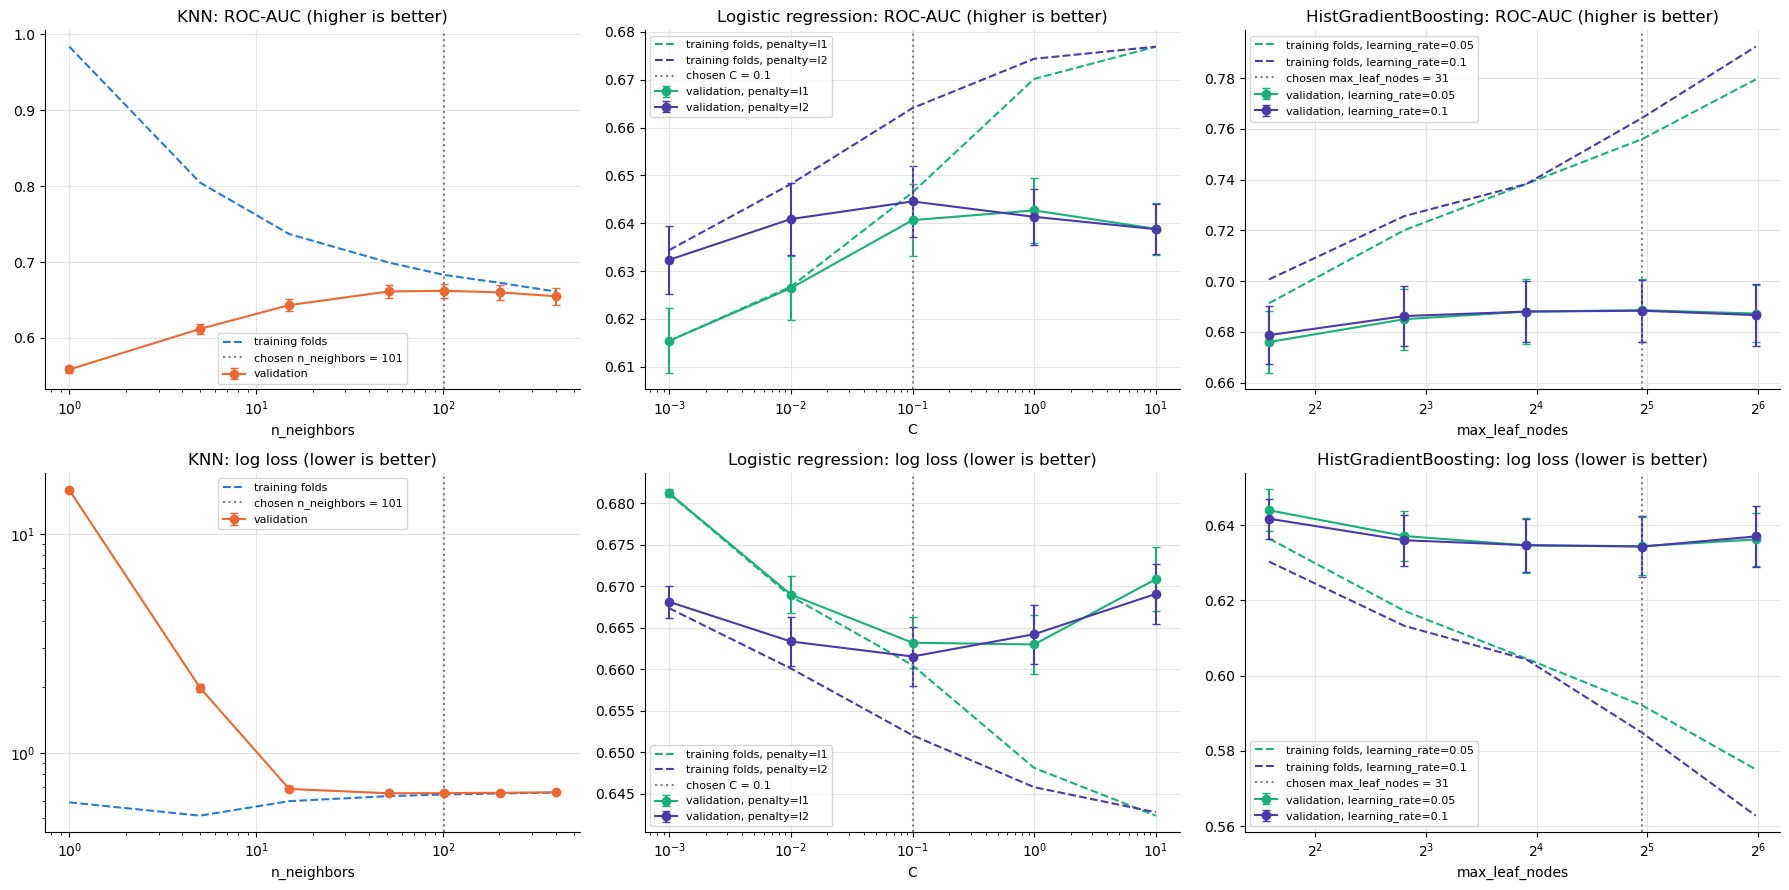

,params,CV ROC-AUC
Dummy (most frequent),-,0.500 ± 0.000
Dummy (always above),-,0.500 ± 0.000
Single threshold (depth-1 tree),-,0.587 ± 0.008
KNN,n_neighbors=101,0.662 ± 0.009
Logistic regression,"C=0.1, penalty=l2",0.645 ± 0.007
HistGradientBoosting,"learning_rate=0.05, max_leaf_nodes=31",0.689 ± 0.012


In [16]:
PLOTS = [("KNN", "n_neighbors", None), ("Logistic regression", "C", "penalty"), ("HistGradientBoosting", "max_leaf_nodes", "learning_rate")]
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for col, (name, param, split_by) in enumerate(PLOTS):
    res = pd.DataFrame(searches[name].cv_results_)
    groups = list(res.groupby(f"param_model__{split_by}")) if split_by else [(None, res)]
    for row, metric in enumerate(["roc_auc", "log_loss"]):
        ax = axes[row, col]
        sign = -1 if metric == "log_loss" else 1  # scikit-learn stores the *negative* log loss
        for j, (value, g) in enumerate(groups):
            x = g[f"param_model__{param}"].astype(float)
            suffix = f", {split_by}={value}" if split_by else ""
            # one model setting: training blue, validation orange; two settings: one colour each, dashed = training
            val_c, tr_c = (["#1baf7a", "#4a3aa7"][j],) * 2 if split_by else (VAL_C, TRAIN_C)
            ax.errorbar(x, sign * g[f"mean_test_{metric}"], yerr=g[f"std_test_{metric}"], fmt="-o", capsize=3,
                        color=val_c, label="validation" + suffix)
            ax.plot(x, sign * g[f"mean_train_{metric}"], "--", color=tr_c, label="training folds" + suffix)
        best = searches[name].best_params_[f"model__{param}"]
        ax.axvline(best, color="grey", ls=":", label=f"chosen {param} = {best}")
        ax.set_xscale("log", base=2 if name == "HistGradientBoosting" else 10)
        ax.set(title=f"{name}: {'ROC-AUC (higher is better)' if row == 0 else 'log loss (lower is better)'}", xlabel=param)
        if name == "KNN" and metric == "log_loss":
            ax.set_yscale("log")  # k = 1 has a validation loss of ~16: its probabilities are only 0 or 1, and every mistake is "certain"
        ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

cv_table = pd.DataFrame(cv_rows).T
cv_table["CV ROC-AUC"] = cv_table.apply(lambda r: f"{r.cv_mean:.3f} ± {r.cv_std:.3f}", axis=1)
cv_table[["params", "CV ROC-AUC"]]

**L1 vs L2 in detail.** We refit logistic regression with each penalty at its own best `C` and compare the coefficients: how many does each penalty set to exactly zero,
and which features weigh most? (Numbers are standardised and categories one-hot encoded, so coefficients are comparable: a positive one raises the chance of "above median".)

In [17]:
lr_res = pd.DataFrame(searches["Logistic regression"].cv_results_)
coef_rows, coefs = {}, {}
for penalty, g in lr_res.groupby("param_model__penalty"):
    best = g.loc[g.mean_test_roc_auc.idxmax()]
    pipe = clone(searches["Logistic regression"].best_estimator_).set_params(model__penalty=penalty, model__C=best.param_model__C)
    pipe.fit(X_tune, y_tune)
    coefs[penalty] = pd.Series(pipe.named_steps["model"].coef_[0], index=pipe.named_steps["prep"].get_feature_names_out())
    is_occ = coefs[penalty].index.str.startswith("cat__OCCP_")
    coef_rows[penalty] = {"best C": best.param_model__C,
                          "CV ROC-AUC": f"{best.mean_test_roc_auc:.3f} ± {best.std_test_roc_auc:.3f}",
                          "coefficients": len(coefs[penalty]),
                          "exactly zero": int((coefs[penalty] == 0).sum()),
                          "detailed occupations set to zero": f"{int((coefs[penalty][is_occ] == 0).sum())} of {is_occ.sum()}"}
display(pd.DataFrame(coef_rows).T)

# the 12 strongest coefficients of each penalty, with occupation codes replaced by their names
def readable(feature):
    col = feature.split("__", 1)[1]
    return OCC_LABEL[int(col[5:])] if col.startswith("OCCP_") else col
both = pd.DataFrame(coefs).rename(index=readable)
both.reindex(both.l2.abs().sort_values(ascending=False).index).head(12).round(3)

,best C,CV ROC-AUC,coefficients,exactly zero,detailed occupations set to zero
l1,1.0,0.643 ± 0.007,437,189,184 of 387
l2,0.1,0.645 ± 0.007,437,0,0 of 387


,l1,l2
occ_group_EAT,0.904,0.706
OFF-Postal Service Mail Carriers,-1.233,-0.600
RPR-Automotive Service Technicians And Mechanics,0.916,0.580
ind_group_UTL,0.662,0.551
MGR-Food Service Managers,0.876,0.539
ind_group_SCA,-0.703,-0.517
MED-Medical Records Specialists,-1.730,-0.483
AGEP,0.457,0.447
COW_5.0,0.596,0.445
occ_group_FIN,-0.417,-0.444


**What L1 shows us.** At the same score, L1 sets **189 of 437 coefficients to exactly zero, including 184 of the 387 detailed occupations**. For about half of the occupations,
knowing the exact job adds nothing beyond its occupation group. That fits the design: the target already compares each worker with their own occupation's median.
L2 keeps every coefficient, but it shrinks them. The table of strongest coefficients should be read with care:
* **Age** (+0.45 per standard deviation) and **federal government employer** (`COW_5`, +0.45 to +0.60) are clear, stable effects.
* The large coefficients of single occupations and groups (e.g. "Meeting, convention and event planners": +1.94 under L1, +0.43 under L2) are **not** stable.
  A detailed occupation always belongs to the same occupation group, so the model can split the effect between the two columns in many ways, and rare occupations have few training rows.
  This is also why L1 and L2 disagree most on exactly these columns.
* L1 would be the better choice if a short, explainable list of features mattered most, since it scores the same with 43% fewer coefficients. We keep the grid's choice (L2)
  so that every model is chosen by the same rule. Logistic regression is not the recommended model either way.

**Reading the curves.** Each panel shows the score on the training folds (dashed) and on the validation folds (solid, ± sd over the 5 folds), top row ROC-AUC, bottom row log loss.
A model **underfits** when both lines are close together but poor, and **overfits** when the training line runs away from the validation line while validation stops improving or gets worse.
* **KNN:** k = 1 is extreme overfitting: training ROC-AUC 0.98 (every training worker is their own nearest neighbour) against 0.56 on validation, and a validation log loss of about 16,
  because every probability is 0 or 1 and every mistake is "certain". With growing k the two lines move towards each other. Validation peaks at k = 51–101 (0.662) and drops again at k = 201–401,
  where the training line has fallen almost onto the validation line: that is the start of underfitting, as the model averages over too many dissimilar workers. Best: k = 101.
* **Logistic regression:** a very small C (strong penalty) underfits: both lines are low and close. The validation log loss is U-shaped with its minimum at C = 0.1; above that, the training score keeps
  improving while validation gets worse, which is overfitting. **L1 vs L2:** with a strong penalty L1 is clearly worse (0.615 vs 0.632 at C = 0.001), because it sets so many coefficients to zero that too little is left.
  With a weak penalty both lines meet, because the penalty hardly matters any more. L2 peaks at C = 0.1 (0.645 ± 0.007), L1 at C = 1 (0.643 ± 0.007), a difference far smaller than the spread over the folds. The grid picks **L2 with C = 0.1**.
* **HistGradientBoosting:** with 3 leaves per tree the model underfits (validation 0.676–0.679, training only ~0.02 higher). Validation improves up to 15–31 leaves (0.688–0.689) and drops slightly at 63 leaves,
  while the training score keeps climbing to 0.78–0.79: from about 31 leaves on, extra complexity is only memorised, which is overfitting. The validation log loss has its minimum at 31 leaves as well.
  The two learning rates are within 0.002 of each other everywhere. The grid picks learning_rate = 0.05 with 31 leaves (0.689 ± 0.012).
* Even at its best setting HGB keeps a clear gap between training (0.76) and validation (0.69). The next cells check where that gap comes from and whether it can be closed.

**Is the ranking real?** All models were scored on the *same* five folds, so we can compare them fold by fold. If one model wins in every fold, the difference is not luck of the split,
even when the error bars of the means overlap.

In [18]:
# the same 5 folds for every model, so the models can be compared fold by fold (a paired comparison)
fold_auc = pd.DataFrame({name: [s.cv_results_[f"split{k}_test_roc_auc"][s.best_index_] for k in range(len(folds))]
                         for name, s in searches.items()}, index=[f"fold {k + 1}" for k in range(len(folds))])
fold_auc["HGB minus KNN"] = fold_auc["HistGradientBoosting"] - fold_auc["KNN"]
fold_auc["KNN minus logistic"] = fold_auc["KNN"] - fold_auc["Logistic regression"]
fold_auc.loc["mean"] = fold_auc.mean()
fold_auc.round(3)

,KNN,Logistic regression,HistGradientBoosting,HGB minus KNN,KNN minus logistic
fold 1,0.667,0.644,0.687,0.021,0.023
fold 2,0.658,0.639,0.677,0.019,0.019
fold 3,0.653,0.651,0.681,0.028,0.003
fold 4,0.656,0.634,0.685,0.029,0.021
fold 5,0.677,0.655,0.712,0.035,0.023
mean,0.662,0.645,0.689,0.026,0.018


HistGradientBoosting beats KNN in **all 5 folds** (by 0.019 to 0.035), and KNN beats logistic regression in all 5 folds (by 0.003 to 0.023, so this second gap is less clear-cut).
The ranking HGB > KNN > logistic regression > single threshold > dummies holds, and it does not depend on which households ended up in which fold.

### Under- or overfitting? Training loss against validation loss

The plots above vary one hyperparameter. Two more views show how the **training loss** and the **validation loss** develop:
1. against the **number of trees** (HistGradientBoosting learns step by step, one tree per step);
2. against the **number of training rows** (learning curves). These show whether a gap between the two lines is caused by too little data (variance, which more data fixes)
   or by a model that is too simple (bias, which more data does not fix).

The loss is the **log loss** (cross-entropy), the quantity the models minimise when they learn: it punishes confident wrong probabilities hardest. Lower is better; always guessing 50% gives 0.693.

**1. Loss against the number of trees (HistGradientBoosting, best settings).**

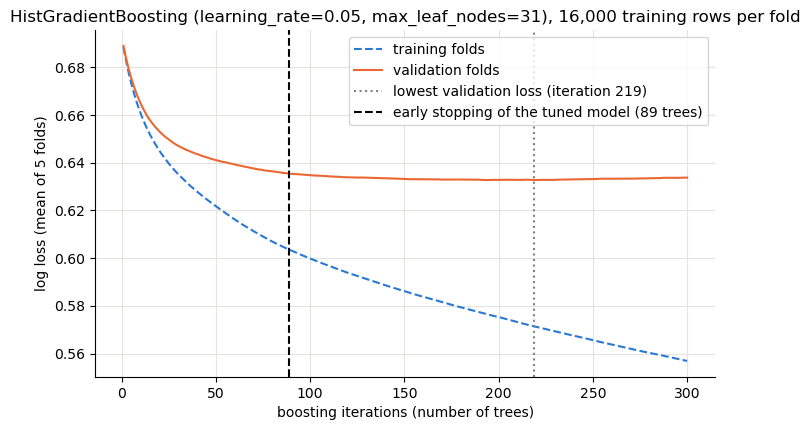

after 219 trees: training loss 0.571, validation loss 0.633
after 300 trees:  training loss 0.557, validation loss 0.634


In [19]:
# HistGradientBoosting adds one tree per iteration. We switch early stopping off, let it run 300 iterations on each training fold
# and record the log loss on the training fold and on the validation fold after every iteration.
hgb_params = {k.replace("model__", ""): v for k, v in searches["HistGradientBoosting"].best_params_.items()}
train_curves, val_curves = [], []
for tr, va in folds:
    pipe = Pipeline([("prep", make_preprocessor()),
                     ("model", HistGradientBoostingClassifier(**hgb_params, max_iter=300, early_stopping=False, random_state=RANDOM_STATE))])
    pipe.fit(X_tune.iloc[tr], y_tune.iloc[tr])
    Xtr, Xva = pipe["prep"].transform(X_tune.iloc[tr]), pipe["prep"].transform(X_tune.iloc[va])
    train_curves.append([log_loss(y_tune.iloc[tr], p[:, 1]) for p in pipe["model"].staged_predict_proba(Xtr)])
    val_curves.append([log_loss(y_tune.iloc[va], p[:, 1]) for p in pipe["model"].staged_predict_proba(Xva)])
train_curve, val_curve = np.mean(train_curves, axis=0), np.mean(val_curves, axis=0)
it = np.arange(1, len(val_curve) + 1)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(it, train_curve, "--", color=TRAIN_C, label="training folds")
ax.plot(it, val_curve, color=VAL_C, label="validation folds")
ax.axvline(val_curve.argmin() + 1, color="grey", ls=":", label=f"lowest validation loss (iteration {val_curve.argmin() + 1})")
stopped = searches["HistGradientBoosting"].best_estimator_["model"].n_iter_
ax.axvline(stopped, color="black", ls="--", label=f"early stopping of the tuned model ({stopped} trees)")
ax.set(xlabel="boosting iterations (number of trees)", ylabel="log loss (mean of 5 folds)",
       title=f"HistGradientBoosting ({', '.join(f'{k}={v}' for k, v in hgb_params.items())}), 16,000 training rows per fold")
ax.legend(); plt.show()
print(f"after {val_curve.argmin() + 1} trees: training loss {train_curve[val_curve.argmin()]:.3f}, validation loss {val_curve.min():.3f}")
print(f"after 300 trees:  training loss {train_curve[-1]:.3f}, validation loss {val_curve[-1]:.3f}")

This is the classic picture of under- and overfitting:
* **First ~50 trees: underfitting.** Both losses fall quickly and stay close together: each new tree still learns patterns that also hold for new workers.
* **From ~100 trees on: overfitting begins.** The training loss keeps falling (0.571 after 219 trees, 0.557 after 300), but the validation loss is flat at 0.633–0.634 and rises slightly after its minimum at 219 trees.
  The trees now learn noise in the training folds. The growing gap between the two lines is the overfitting.
* **Early stopping** watches its own small validation set (10% of the training rows) and stops after 10 trees without improvement. On the 20,000-row sample it stopped the tuned model at 89 trees,
  a little earlier than the minimum. That costs about 0.002 validation log loss (0.635 instead of 0.633), but it never lets the model run into the overfitting region.

**2. Learning curves: loss against the number of training rows** (best settings of each model, the same 5 folds, from 5% to 100% of each training fold).

KNN                  training 0.664 -> 0.644 | validation 0.671 -> 0.653  (799 -> 15,997 rows)


Logistic regression  training 0.633 -> 0.652 | validation 0.671 -> 0.662  (799 -> 15,997 rows)


HistGradientBoosting training 0.548 -> 0.590 | validation 0.683 -> 0.634  (799 -> 15,997 rows)


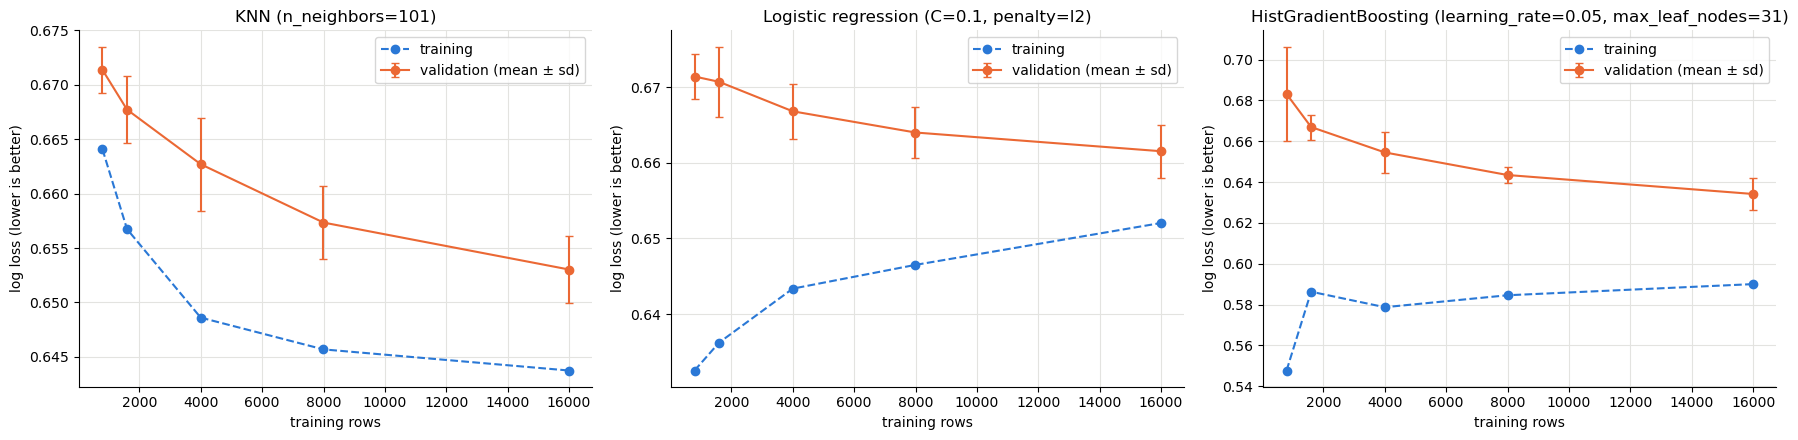

In [20]:
# learning curves: train on 5% ... 100% of each training fold (best settings, same folds) and record the log loss
LC_FRACTIONS = [0.05, 0.1, 0.25, 0.5, 1.0]
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))  # own y-axis per model: HGB's small-sample losses would flatten the others
for ax, name in zip(axes, searches):
    sizes, tr, va = learning_curve(clone(searches[name].best_estimator_), X_tune, y_tune, cv=folds,
                                   train_sizes=LC_FRACTIONS, scoring="neg_log_loss", n_jobs=-1)
    ax.plot(sizes, -tr.mean(axis=1), "--o", color=TRAIN_C, label="training")
    ax.errorbar(sizes, -va.mean(axis=1), yerr=va.std(axis=1), fmt="-o", capsize=3, color=VAL_C, label="validation (mean ± sd)")
    ax.set(title=f"{name} ({cv_rows[name]['params']})", xlabel="training rows", ylabel="log loss (lower is better)")
    ax.legend()
    print(f"{name:20s} training {-tr.mean(axis=1)[0]:.3f} -> {-tr.mean(axis=1)[-1]:.3f} | "
          f"validation {-va.mean(axis=1)[0]:.3f} -> {-va.mean(axis=1)[-1]:.3f}  ({sizes[0]:,} -> {sizes[-1]:,} rows)")
plt.tight_layout(); plt.show()

* **Logistic regression: underfitting (bias).** With more rows the training loss *rises* (0.633 → 0.652) and the validation loss falls only slowly (0.671 → 0.662). The two lines converge at a high loss:
  the model cannot even describe its training data well. One straight-line boundary cannot represent interactions such as "age pays off more in some occupations", and more rows of the same kind will not change that.
* **KNN:** a small gap (~0.01), and the validation loss is still falling at 16,000 rows (0.671 → 0.653). With more data its 101 neighbours become more similar to the worker, so it may gain a bit more.
* **HistGradientBoosting: overfitting (variance).** It has by far the lowest validation loss (0.683 → 0.634), but also the largest gap to its training loss (0.59 at 16,000 rows),
  and the validation loss is still clearly falling. A gap that shrinks as rows are added is **variance**, which more data reduces.
* So the honest question is: what happens with more than 20,000 rows? We have ~870,000 training workers, so we can check it without touching the test set.

**3. Beyond the tuning sample.** We set aside 10% of the training **households** as a validation set and fit each model (same settings) on 20,000, 60,000 and 200,000 workers from the other 90%.
KNN stops at 60,000 rows, because it compares every prediction with every training row. The test set is still not used.

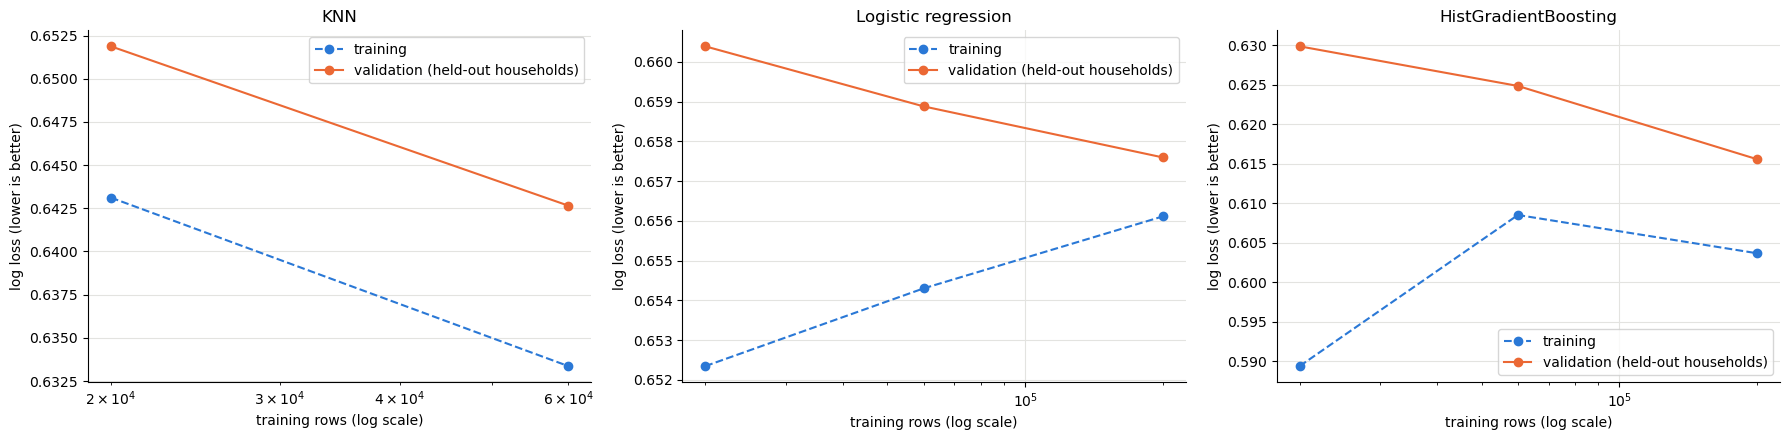

train log loss  validation log loss  train ROC-AUC  validation ROC-AUC  seconds
model                training rows                                                                                 
HistGradientBoosting 20000                   0.589                0.630          0.760               0.697    8.105
                     60000                   0.609                0.625          0.731               0.705   18.771
                     200000                  0.604                0.616          0.735               0.716   88.125
Logistic regression  20000                   0.652                0.660          0.668               0.649    0.328
                     60000                   0.654                0.659          0.663               0.651    0.595
                     200000                  0.656                0.658          0.659               0.654    2.998
KNN                  20000                   0.643                0.652          0.685               0.666    8.339
                     60000                   0.633                0.643          0.699               0.682   25.817

In [21]:
# 10% of the training *households* become a validation set; the models learn from growing samples of the other 90%.
# The test set is still untouched.
fit_idx, val_idx = next(GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=RANDOM_STATE).split(train, groups=train.SERIALNO))
train_fit, val = train.iloc[fit_idx], train.iloc[val_idx]
val_s = val.sample(N_TUNE, random_state=RANDOM_STATE)  # fixed 20k validation rows for the curve (KNN predicts slowly)
SIZES = {"HistGradientBoosting": [20_000, 60_000, 200_000],
         "Logistic regression": [20_000, 60_000, 200_000],
         "KNN": [20_000, 60_000]}  # KNN compares each prediction with every training row, so it gets slow quickly

more_rows, big_models = [], {}
for name, sizes in SIZES.items():
    for n in sizes:
        start = time.time()
        sample = train_fit.sample(n, random_state=RANDOM_STATE)
        pipe = clone(searches[name].best_estimator_).fit(sample[FEATURES], sample.y)
        seen = sample.iloc[:N_TUNE]  # training score on 20k of the rows it learned from
        p_seen, p_val = pipe.predict_proba(seen[FEATURES])[:, 1], pipe.predict_proba(val_s[FEATURES])[:, 1]
        more_rows.append({"model": name, "training rows": n,
                          "train log loss": log_loss(seen.y, p_seen), "validation log loss": log_loss(val_s.y, p_val),
                          "train ROC-AUC": roc_auc_score(seen.y, p_seen), "validation ROC-AUC": roc_auc_score(val_s.y, p_val),
                          "seconds": time.time() - start})
        big_models[(name, n)] = pipe
more = pd.DataFrame(more_rows)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, name in zip(axes, ["KNN", "Logistic regression", "HistGradientBoosting"]):
    m = more[more.model == name]
    ax.plot(m["training rows"], m["train log loss"], "--o", color=TRAIN_C, label="training")
    ax.plot(m["training rows"], m["validation log loss"], "-o", color=VAL_C, label="validation (held-out households)")
    ax.set_xscale("log"); ax.set(title=name, xlabel="training rows (log scale)", ylabel="log loss (lower is better)"); ax.legend()
plt.tight_layout(); plt.show()
more.set_index(["model", "training rows"]).round(3)

* **HistGradientBoosting** keeps improving: validation ROC-AUC 0.697 → 0.705 → 0.716 and validation log loss 0.630 → 0.625 → 0.616 from 20k to 200k rows. At the same time the gap between
  training and validation ROC-AUC shrinks from 0.06 to 0.02. **The overfitting at 20,000 rows was mostly a lack of data, and more data cures it.**
  (The training loss does not fall smoothly, because early stopping picks a different number of trees at each size.)
* **Logistic regression** does not improve (0.649 → 0.654) and its training and validation loss meet at ~0.657: it is **underfitting**, and more data cannot help a model that is too simple.
* **KNN** also gains from more rows (0.666 → 0.682 at 60,000): with more data, its 101 neighbours are more similar to the worker. But it stays well below HGB at the same size (0.705),
  so the ranking of the model types does not change, while KNN's predictions get slower with every extra row.
* **Decision (made here, on training data only):** the comparison of the three model types stays on the same 20,000 rows, which is fair. The **recommended model** is HistGradientBoosting with its tuned settings,
  **refitted on 200,000 training workers**. All ~785,000 rows would add a little more (about 0.725 in a single check we ran outside this notebook), but that fit takes about 9 minutes on a 12-core laptop,
  far too long for Colab. The 10% validation households are kept out of this model, so they can be used to choose the signal threshold in step 8.

In [22]:
BIG_N = 200_000
RECOMMENDED = "HistGradientBoosting (200k rows)"  # same settings as the tuned HGB, fitted on 200,000 training workers

## 7. Evaluate once on the test set

Each model is refitted on the full tuning sample with its best settings (GridSearchCV does this automatically), then predicts the 50,000 test workers **once**.
The recommended model from step 6 (HistGradientBoosting on 200,000 rows) is evaluated in the same pass. Its "CV" column is its score on the held-out validation households instead.
Per model: confusion matrix, precision, recall and F1 at the default threshold of 0.5, ROC-AUC (the main metric) and log loss.

In [23]:
final_models = {name: pipe.fit(X_tune, y_tune) for name, pipe in baselines.items()}
final_models.update({name: s.best_estimator_ for name, s in searches.items()})
final_models[RECOMMENDED] = big_models[("HistGradientBoosting", BIG_N)]  # same settings, more rows (step 6)

rows, preds = [], {}
for name, model in final_models.items():
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    preds[name] = (pred, prob)
    if name == RECOMMENDED:
        m = more[(more.model == "HistGradientBoosting") & (more["training rows"] == BIG_N)].iloc[0]
        train_auc, cv = m["train ROC-AUC"], f"{m['validation ROC-AUC']:.3f} (held-out households)"
    else:
        train_auc = roc_auc_score(y_tune, model.predict_proba(X_tune)[:, 1])
        cv = f"{cv_rows[name]['cv_mean']:.3f} ± {cv_rows[name]['cv_std']:.3f}"
    rows.append({
        "Model": name,
        "Best hyperparameters": cv_rows["HistGradientBoosting" if name == RECOMMENDED else name]["params"],
        "Training rows": BIG_N if name == RECOMMENDED else N_TUNE,
        "Train ROC-AUC": train_auc,
        "CV ROC-AUC (mean ± sd)": cv,
        "Test ROC-AUC": roc_auc_score(y_test, prob),
        "Test log loss": log_loss(y_test, prob),
        "Test precision": precision_score(y_test, pred, zero_division=0),
        "Test recall": recall_score(y_test, pred),
        "Test F1": f1_score(y_test, pred),
    })
comparison = pd.DataFrame(rows).set_index("Model")
comparison.to_csv("comparison_table.csv", float_format="%.3f")
comparison.round(3)

,Best hyperparameters,Training rows,Train ROC-AUC,CV ROC-AUC (mean ± sd),Test ROC-AUC,Test log loss,Test precision,Test recall,Test F1
Model,,,,,,,,,
Dummy (most frequent),-,20000,0.500,0.500 ± 0.000,0.500,17.836,0.000,0.000,0.000
Dummy (always above),-,20000,0.500,0.500 ± 0.000,0.500,18.208,0.495,1.000,0.662
Single threshold (depth-1 tree),-,20000,0.590,0.587 ± 0.008,0.589,0.672,0.554,0.834,0.666
KNN,n_neighbors=101,20000,0.686,0.662 ± 0.009,0.664,0.652,0.604,0.661,0.631
Logistic regression,"C=0.1, penalty=l2",20000,0.663,0.645 ± 0.007,0.647,0.661,0.607,0.594,0.600
HistGradientBoosting,"learning_rate=0.05, max_leaf_nodes=31",20000,0.732,0.689 ± 0.012,0.690,0.635,0.625,0.662,0.643
HistGradientBoosting (200k rows),"learning_rate=0.05, max_leaf_nodes=31",200000,0.735,0.716 (held-out households),0.717,0.616,0.648,0.668,0.658


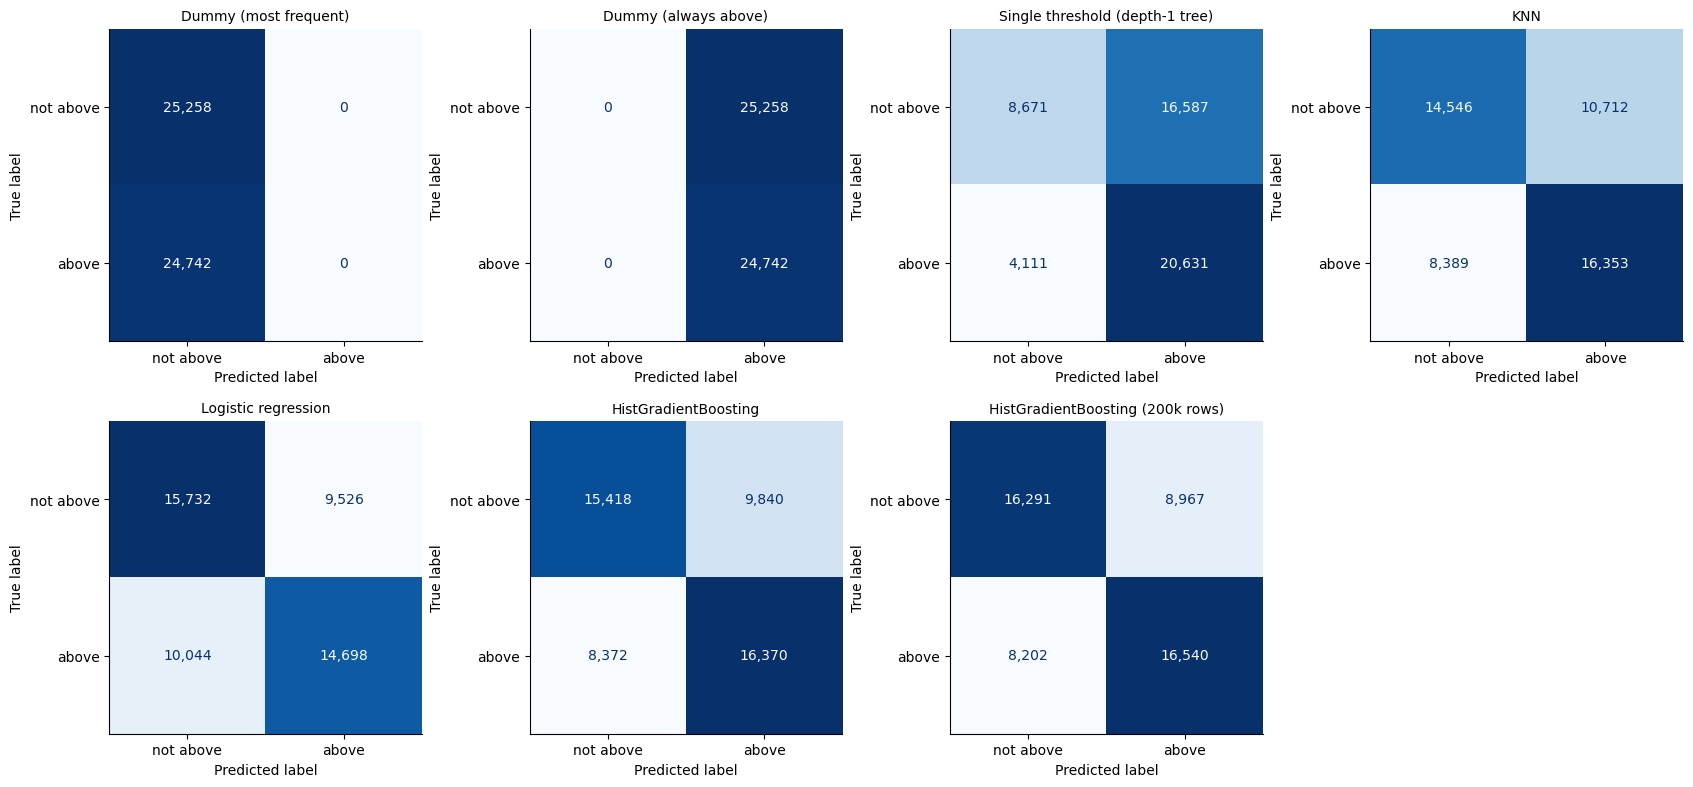

In [24]:
fig, axes = plt.subplots(2, 4, figsize=(17, 8))
for ax, (name, (pred, _)) in zip(axes.flat, preds.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=["not above", "above"]).plot(
        ax=ax, colorbar=False, values_format=",", cmap="Blues")
    ax.set_title(name, fontsize=10); ax.grid(False)
axes.flat[-1].axis("off")
plt.tight_layout(); plt.show()

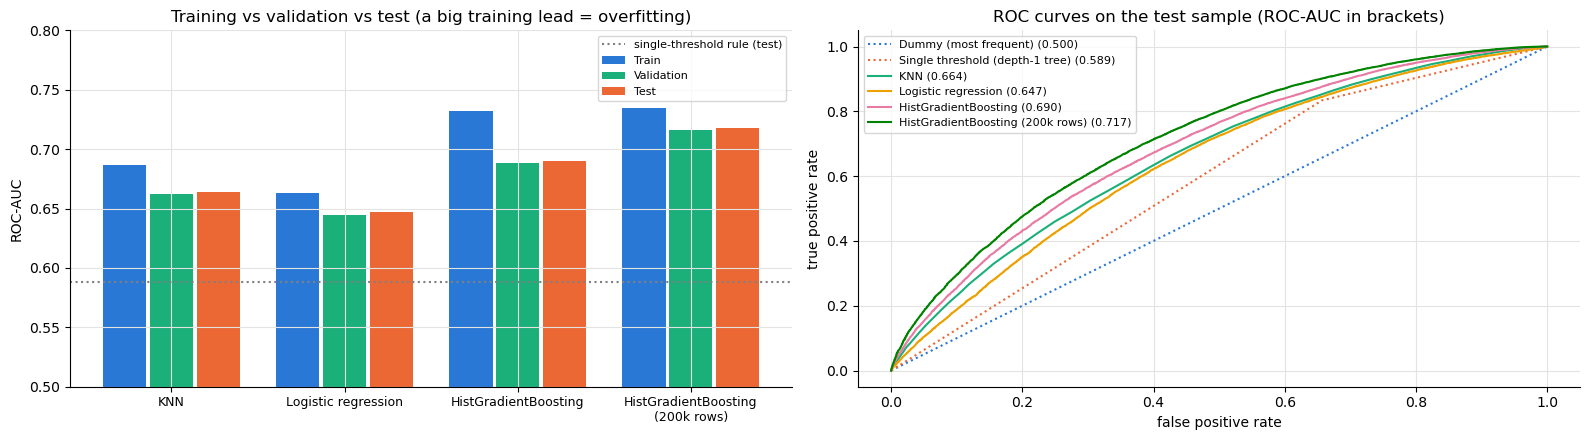

In [25]:
# the gaps between training, validation and test score per model, in one picture
gap = comparison.loc[list(searches) + [RECOMMENDED], ["Train ROC-AUC", "Test ROC-AUC"]].copy()
gap["Validation ROC-AUC"] = [cv_rows[n]["cv_mean"] for n in searches] + [float(comparison.loc[RECOMMENDED, "CV ROC-AUC (mean ± sd)"].split()[0])]
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
x = np.arange(len(gap))
for k, (col, colour) in enumerate([("Train ROC-AUC", TRAIN_C), ("Validation ROC-AUC", "#1baf7a"), ("Test ROC-AUC", VAL_C)]):
    axes[0].bar(x + (k - 1) * 0.27, gap[col], width=0.25, color=colour, label=col.replace(" ROC-AUC", ""))
axes[0].set_xticks(x, [n.replace(" (", "\n(") for n in gap.index], fontsize=9)
axes[0].set(ylim=(0.5, 0.8), ylabel="ROC-AUC", title="Training vs validation vs test (a big training lead = overfitting)")
axes[0].axhline(comparison.loc["Single threshold (depth-1 tree)", "Test ROC-AUC"], color="grey", ls=":", label="single-threshold rule (test)")
axes[0].legend(fontsize=8)
for name, (_, prob) in preds.items():
    if name.startswith("Dummy (always"):
        continue  # identical to the other dummy: the diagonal
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[1].plot(fpr, tpr, ls=":" if name.startswith(("Dummy", "Single")) else "-",
                 label=f"{name} ({roc_auc_score(y_test, prob):.3f})")
axes[1].set(xlabel="false positive rate", ylabel="true positive rate", title="ROC curves on the test sample (ROC-AUC in brackets)")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Train vs CV vs test.**
* **CV and test agree for every model** (within 0.003 ROC-AUC). The CV estimate was honest, and the test set (other households, never used for any choice) confirms it.
  The 200k model scores 0.716 on the validation households and 0.717 on test.
* **HistGradientBoosting on 20,000 rows overfits:** 0.73 on its own training data against 0.69 on CV and test. **Refitted on 200,000 rows** the gap shrinks to 0.02 (0.735 vs 0.717), and the test score rises by 0.027.
  That is the biggest single improvement in the notebook, and it came from more data, not from a different model.
* **KNN** has a gap of 0.02 (0.69 vs 0.66). Part of its training score is optimistic, because each training point counts as its own neighbour.
* **Logistic regression** has almost no gap (0.66 vs 0.65), but it is low everywhere: it **underfits** (see the learning curves in step 6).
* **The F1 column shows why F1 was dropped:** "always above" (0.662) and the single threshold (0.666) have a *higher* F1 than KNN and logistic regression, yet they cannot rank anyone (ROC-AUC 0.50 and 0.59).
  The ROC curves show the same: the dummy is the diagonal, and the recommended model's curve lies above all others everywhere.
* **In absolute terms all models are modest.** A ROC-AUC of 0.72 means: for a random above-median and below-median worker, the recommended model ranks them correctly about 7 times in 10.
  The job profile explains part, but not most, of who earns above their median. The rest is employer, tenure, performance, negotiation and also discrimination, none of which the data contain.

## 8. Look at the errors

We look more closely at the **recommended model**: the model type with the best cross-validation ROC-AUC (HistGradientBoosting),
refitted on 200,000 training workers (step 6). It was chosen on training data only, not on the test set.

In [26]:
# step 6 chose the model type on CV; the recommended model is that type, refitted on more rows
print("best model type by CV ROC-AUC:", max(searches, key=lambda n: cv_rows[n]["cv_mean"]), "| model examined here:", RECOMMENDED)
pred, prob = preds[RECOMMENDED]
err = test_s.assign(pred=pred, prob=prob)
err["outcome"] = np.select([(err.y == 1) & (err.pred == 1), (err.y == 0) & (err.pred == 1), (err.y == 1) & (err.pred == 0)],
                           ["TP", "FP", "FN"], "TN")

err["hours_band"] = pd.cut(err.WKHP, [0, 34, 44, 99], labels=["<35 h (part-time)", "35-44 h", "45+ h"])
err["age_band"] = pd.cut(err.AGEP, [17, 24, 34, 49, 64], labels=["18-24", "25-34", "35-49", "50-64"])
for col in ["hours_band", "age_band"]:
    print(pd.crosstab(err[col], err.outcome, normalize="index").round(3)[["TP", "FP", "FN", "TN"]], "\n")

best model type by CV ROC-AUC: HistGradientBoosting | model examined here: HistGradientBoosting (200k rows)
outcome               TP     FP     FN     TN
hours_band                                   
<35 h (part-time)  0.165  0.112  0.230  0.492
35-44 h            0.362  0.197  0.151  0.290
45+ h              0.370  0.182  0.150  0.299 

outcome      TP     FP     FN     TN
age_band                            
18-24     0.026  0.019  0.232  0.723
25-34     0.171  0.106  0.245  0.478
35-49     0.422  0.221  0.135  0.221
50-64     0.468  0.251  0.109  0.173 



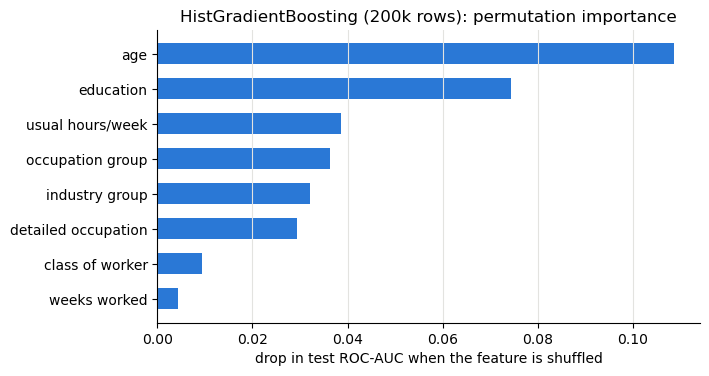

In [27]:
# which features does the recommended model rely on? Shuffle one feature at a time in the test sample and measure the drop in ROC-AUC.
imp = permutation_importance(final_models[RECOMMENDED], X_test, y_test, scoring="roc_auc", n_repeats=3,
                             random_state=RANDOM_STATE, n_jobs=-1)
imp = pd.Series(imp.importances_mean, index=FEATURES).sort_values()
NAMES = {"AGEP": "age", "SCHL": "education", "WKHP": "usual hours/week", "WKWN": "weeks worked", "OCCP": "detailed occupation",
         "occ_group": "occupation group", "ind_group": "industry group", "COW": "class of worker"}
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.barh(imp.index.map(NAMES), imp, color=TRAIN_C, height=0.6)
ax.set(xlabel="drop in test ROC-AUC when the feature is shuffled", title=f"{RECOMMENDED}: permutation importance")
ax.grid(axis="y", visible=False); plt.show()

**What the model relies on.** Shuffling **age** costs the most ROC-AUC (about 0.11), followed by **education** (about 0.07). Hours, occupation group, industry group and detailed occupation each add about 0.03;
class of worker and weeks worked hardly matter. So the model mainly learns "experience and education pay off, more in some jobs than in others".
**Caution with hours:** usual hours per week is also in the denominator of the hourly wage (yearly wage ÷ hours × weeks). If someone over-reports their hours, their computed hourly wage drops and the model,
which also sees those hours, partly learns this reporting effect. An adviser should therefore check the hours before acting on a signal.

In [28]:
# the most confident wrong 'above median' predictions = the workers who would get the strongest 'you may be underpaid' signals
show = ["OCCP", "STATE", "AGEP", "SCHL", "WKHP", "WKWN", "COW", "hourly", "cell_median", "prob"]
fp = err[err.outcome == "FP"].nlargest(8, "prob")[show].assign(occupation=lambda d: d.OCCP.map(OCC_LABEL),
                                                               state=lambda d: d.STATE.map(STATE_LABEL))
fp.round(2)

,OCCP,STATE,AGEP,SCHL,WKHP,WKWN,COW,hourly,cell_median,prob,occupation,state
33303,1555,6,63,20.0,40.0,52.0,1.0,25.38,32.16,0.92,ENG-Other Engineering Technologists And Techni...,California/CA
47748,2300,12,43,22.0,8.0,52.0,3.0,7.81,15.19,0.92,EDU-Preschool And Kindergarten Teachers,Florida/FL
19527,940,6,60,22.0,40.0,52.0,1.0,7.32,30.68,0.89,FIN-Tax Preparers,California/CA
168799,3300,42,59,24.0,50.0,52.0,1.0,22.65,24.41,0.88,MED-Clinical Laboratory Technologists And Tech...,Pennsylvania/PA
54271,2300,12,36,21.0,40.0,15.0,3.0,12.69,15.19,0.88,EDU-Preschool And Kindergarten Teachers,Florida/FL
82526,1555,19,57,16.0,43.0,52.0,1.0,22.70,28.20,0.88,ENG-Other Engineering Technologists And Techni...,Iowa/IA
121175,2722,34,37,23.0,40.0,52.0,1.0,27.82,29.29,0.88,ENT-Coaches and Scouts,New Jersey/NJ
55964,1050,12,56,21.0,40.0,52.0,5.0,26.85,30.26,0.86,CMM-Computer Support Specialists,Florida/FL


### Performance per group

The sensitive columns were **not** given to the model. Here we use them to check whether its mistakes are spread evenly.
*FPR* = share of below-median workers wrongly predicted "above" (would receive a wrong signal); *FNR* = share of above-median workers missed.

In [29]:
def group_report(d, col, p="pred"):
    out = {}
    for g, s in d.groupby(col, observed=True):
        tn, fp_, fn, tp = confusion_matrix(s.y, s[p], labels=[0, 1]).ravel()
        out[g] = {"n": len(s), "actual above": s.y.mean(), "predicted above": s[p].mean(),
                  "precision": tp / max(tp + fp_, 1), "recall": tp / max(tp + fn, 1),
                  "F1": f1_score(s.y, s[p], zero_division=0),
                  "FPR": fp_ / max(fp_ + tn, 1), "FNR": fn / max(fn + tp, 1)}
    return pd.DataFrame(out).T.round(3)

for col in AUDIT:
    display(group_report(err, col))
err["sector"] = err.occ_group + " – " + err.occ_group.map(OCC_GROUP_NAME)
group_report(err, "sector").sort_values("F1")

,n,actual above,predicted above,precision,recall,F1,FPR,FNR
female,24912.0,0.455,0.491,0.607,0.655,0.630,0.353,0.345
male,25088.0,0.535,0.530,0.686,0.680,0.683,0.357,0.320


,n,actual above,predicted above,precision,recall,F1,FPR,FNR
Asian,3871.0,0.536,0.615,0.650,0.746,0.695,0.464,0.254
Black,3785.0,0.469,0.511,0.608,0.662,0.634,0.377,0.338
Hispanic,8890.0,0.434,0.407,0.588,0.552,0.569,0.296,0.448
Other/multiple,2723.0,0.466,0.464,0.632,0.629,0.631,0.320,0.371
White,30731.0,0.513,0.531,0.668,0.691,0.679,0.362,0.309


,n,actual above,predicted above,precision,recall,F1,FPR,FNR
born US citizen,41802.0,0.492,0.496,0.655,0.660,0.657,0.337,0.340
naturalised citizen,4417.0,0.561,0.643,0.658,0.754,0.703,0.501,0.246
non-citizen,3781.0,0.448,0.513,0.566,0.648,0.604,0.404,0.352


,n,actual above,predicted above,precision,recall,F1,FPR,FNR
"EXT – Extraction (mining, oil and gas)",16.0,0.500,0.438,0.571,0.500,0.533,0.375,0.500
CLN – Building and grounds cleaning and maintenance,1318.0,0.507,0.451,0.603,0.536,0.567,0.363,0.464
HLS – Healthcare support,1651.0,0.499,0.474,0.604,0.573,0.588,0.375,0.427
"FFF – Farming, fishing and forestry",257.0,0.486,0.436,0.634,0.568,0.599,0.311,0.432
EAT – Food preparation and serving,2563.0,0.477,0.510,0.586,0.626,0.605,0.404,0.374
PRD – Production,2250.0,0.498,0.532,0.601,0.642,0.621,0.422,0.358
TRN – Transportation and material moving,3634.0,0.506,0.532,0.624,0.658,0.641,0.405,0.342
CON – Construction,1879.0,0.489,0.530,0.622,0.674,0.647,0.392,0.326
PRS – Personal care and service,706.0,0.508,0.510,0.647,0.649,0.648,0.366,0.351
OFF – Office and administrative support,5510.0,0.495,0.507,0.641,0.657,0.649,0.360,0.343


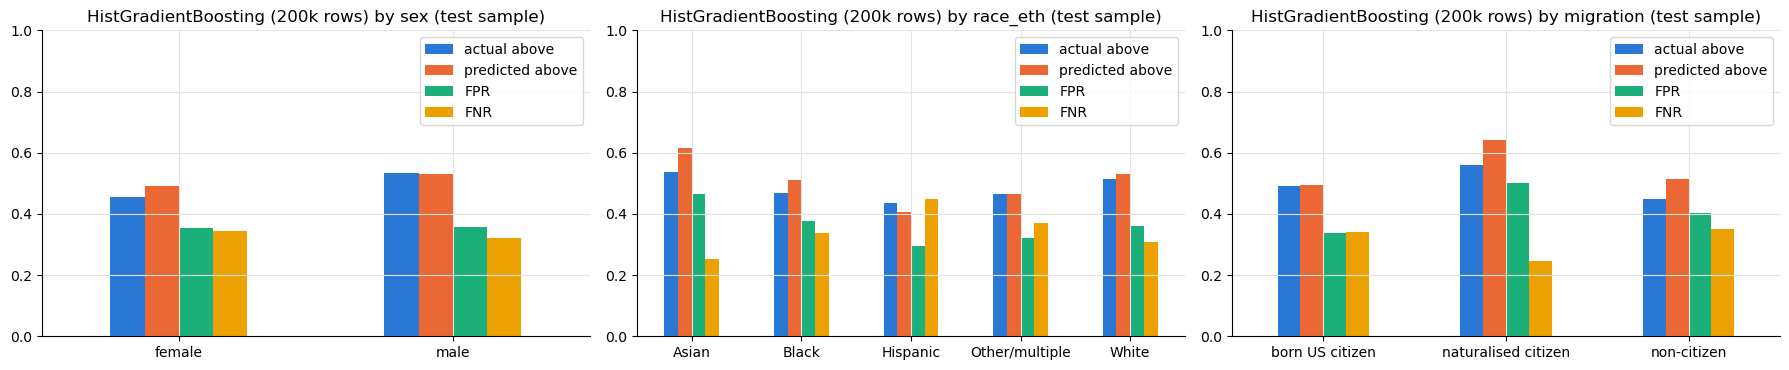

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 3.8))
for ax, col in zip(axes, AUDIT):
    group_report(err, col)[["actual above", "predicted above", "FPR", "FNR"]].plot.bar(ax=ax, rot=0)
    ax.set(title=f"{RECOMMENDED} by {col} (test sample)", ylim=(0, 1))
plt.tight_layout(); plt.show()

### Rare occupations in the tuning sample

The 30-worker rule makes each *median* reliable, and it is checked on all ~870k training workers. The models, however, learn from the 20k tuning sample,
where many occupations appear only a few times or not at all. An occupation the model never saw becomes all zeros in the one-hot encoding,
so the model falls back on the occupation group, age, education and hours. Does that make predictions worse? We group the test workers by how often their occupation appears in the tuning sample.

In [31]:
occ_n = tune.OCCP.value_counts()
covered_occ = covered_cells.OCCP.drop_duplicates()
print(f"{len(covered_occ)} occupations are covered in at least one state; {len(occ_n)} appear in the tuning sample; "
      f"{(~covered_occ.isin(occ_n.index)).sum()} covered occupations never appear in it")

err["occ_in_tune"] = pd.cut(err.OCCP.map(occ_n).fillna(0), [-1, 0, 9, 49, np.inf],
                            labels=["0 (unseen)", "1-9", "10-49", "50+"])
rows = {}
for band in err.occ_in_tune.cat.categories:
    mask = (err.occ_in_tune == band).to_numpy()
    if mask.sum() == 0:  # no test worker in this band
        continue
    rows[band] ={"test workers": mask.sum(), "share of test": mask.mean(),
                  **{f"ROC-AUC {name}": roc_auc_score(y_test[mask], preds[name][1][mask]) for name in [*searches, RECOMMENDED]}}
pd.DataFrame(rows).T.rename_axis("workers with this occupation in the tuning sample").round(3)

409 occupations are covered in at least one state; 387 appear in the tuning sample; 22 covered occupations never appear in it


,test workers,share of test,ROC-AUC KNN,ROC-AUC Logistic regression,ROC-AUC HistGradientBoosting,ROC-AUC HistGradientBoosting (200k rows)
workers with this occupation in the tuning sample,,,,,,
0 (unseen),64.0,0.001,0.719,0.667,0.736,0.695
1-9,1453.0,0.029,0.673,0.660,0.687,0.698
10-49,6592.0,0.132,0.660,0.638,0.687,0.715
50+,41891.0,0.838,0.665,0.648,0.691,0.719


**Result: the small sample costs little.**
* 22 of the 409 covered occupations never appear in the tuning sample, but they account for only 64 test workers (0.1%). That is too few to judge their score.
* Workers whose occupation appears only 1–9 times (3% of the test set) get a slightly lower ROC-AUC from HistGradientBoosting (0.68 vs 0.69–0.70 for common occupations).
  With about 1,500 workers, this difference is within normal variation.
* **84% of test workers** have an occupation that appears 50+ times in the sample.
* This fits the design: the target is already defined *per occupation*, so the occupation on its own predicts almost nothing. The models mainly use age, education, hours and weeks, which every sampled worker contributes to.
* For the recommended model refitted on 200,000 rows the question mostly disappears: it scores 0.70 for occupations seen 1–9 times in the *tuning* sample and 0.72 for common ones, because the larger sample contains many more workers from rare occupations.

**Proxy check.** Removing sex, race and citizenship from the features does not mean the model cannot "see" them. Occupation, industry and hours differ strongly between groups.
We test how well the model's own features predict each sensitive attribute (logistic regression, same folds). A ROC-AUC of 0.5 means "no information" and 1.0 means "perfectly hidden in the features".

In [32]:
proxy = {}
for target_name, target in [("female", tune.sex == "female"), ("non-citizen", tune.migration == "non-citizen"),
                            ("Black", tune.race_eth == "Black"), ("Hispanic", tune.race_eth == "Hispanic")]:
    pipe = Pipeline([("prep", make_preprocessor()), ("model", LogisticRegression(max_iter=2000))])
    proxy[target_name] = cross_validate(pipe, X_tune, target, cv=folds, scoring="roc_auc")["test_score"].mean()
pd.Series(proxy, name="ROC-AUC of predicting it from the model's features").round(3).to_frame()

,ROC-AUC of predicting it from the model's features
female,0.810
non-citizen,0.715
Black,0.627
Hispanic,0.676


### Mitigation: a strict threshold for the "underpaid" signal

The signal goes to workers whose profile the model rates as "usually above the median" (probability ≥ threshold) but who actually earn below it. In classifier terms, the **workers who get a signal are exactly
its false positives at that threshold**, and the precision at the threshold is the share of workers with such a profile who *do* earn above the median.
A precision of 80% therefore does **not** mean "80% of signals are right". It means: a member gets a signal only if at least 4 in 5 comparable profiles earn more than they do.
The higher this bar, the more unusual the member's low pay is for their profile, and the less likely the signal is just normal variation (step 1: an unjustified signal is the worse mistake).

We choose the lowest threshold that reaches 80% precision on the **validation households** from step 6 (not used to fit the recommended model, and not the test set). We then report what it does on the test set
and per group, including the share of workers in each group who would get a signal.

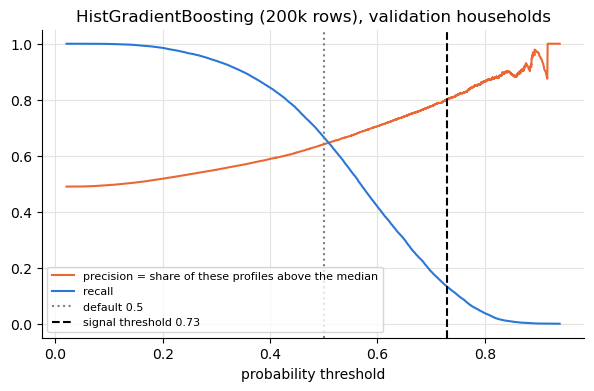

threshold 0.729 on the test sample: precision 0.805, recall 0.134 (at 0.5: precision 0.648, recall 0.668)
8.2% of test workers have a 'usually above' profile; 1.6% of all test workers would get a signal


,n,precision,recall,share with signal
female,24912.0,0.759,0.129,0.019
male,25088.0,0.845,0.138,0.014


,n,precision,recall,share with signal
Asian,3871.0,0.802,0.209,0.028
Black,3785.0,0.728,0.114,0.020
Hispanic,8890.0,0.743,0.080,0.012
Other/multiple,2723.0,0.762,0.109,0.016
White,30731.0,0.826,0.142,0.015


,n,precision,recall,share with signal
born US citizen,41802.0,0.811,0.125,0.014
naturalised citizen,4417.0,0.794,0.209,0.030
non-citizen,3781.0,0.758,0.131,0.019


In [33]:
# The signal threshold is chosen on the held-out validation households (not used to fit the recommended model, and not the test set).
TARGET_PRECISION = 0.80
val_prob = final_models[RECOMMENDED].predict_proba(val[FEATURES])[:, 1]
prec, rec, thr = precision_recall_curve(val.y, val_prob)
FLAG_THRESHOLD = float(thr[np.argmax(prec[:-1] >= TARGET_PRECISION)])  # lowest threshold at which >= 80% of profiles are above the median

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thr, prec[:-1], color=VAL_C, label="precision = share of these profiles above the median")
ax.plot(thr, rec[:-1], color=TRAIN_C, label="recall")
ax.axvline(0.5, color="grey", ls=":", label="default 0.5")
ax.axvline(FLAG_THRESHOLD, color="black", ls="--", label=f"signal threshold {FLAG_THRESHOLD:.2f}")
ax.set(xlabel="probability threshold", title=f"{RECOMMENDED}, validation households"); ax.legend(fontsize=8)
plt.show()

err["flag_pred"] = (err.prob >= FLAG_THRESHOLD).astype(int)
err["signal"] = (err.flag_pred == 1) & (err.y == 0)  # profile usually above the median, but this worker is not
print(f"threshold {FLAG_THRESHOLD:.3f} on the test sample: precision {precision_score(err.y, err.flag_pred):.3f}, "
      f"recall {recall_score(err.y, err.flag_pred):.3f} (at 0.5: precision {precision_score(err.y, err.pred):.3f}, "
      f"recall {recall_score(err.y, err.pred):.3f})")
print(f"{err.flag_pred.mean():.1%} of test workers have a 'usually above' profile; {err.signal.mean():.1%} of all test workers would get a signal")
for col in AUDIT:
    rep = group_report(err, col, p="flag_pred")[["n", "precision", "recall"]]
    rep["share with signal"] = err.groupby(col).signal.mean().round(3)
    display(rep)

**What the errors tell us.**
* **Age dominates.** Workers under 25 are almost always predicted "below" (2.6% true positives, 23% misses). Workers over 50 are mostly predicted "above", so most wrong "above" predictions are among workers aged 35+.
  Part-time workers are mostly predicted "below". The permutation importance confirms this: age and education carry the model.
* **The strongest signals** (the most confident wrong "above" predictions) go to older, highly educated people in mid-paid jobs, such as engineering technicians aged 57–63 or a 60-year-old tax preparer with a master's degree.
  The model learned "education and experience pay". For these people a signal *may* reflect underpayment, but it may just as well mean the degree is not used in this job (over-qualification).
  Some of these cases also look like **measurement errors** (a computed hourly wage of $7 for a master's degree holder, or a preschool teacher working 8 hours a week), so an adviser has to check the wage and hours first.
* **Groups (default threshold):** for **women**, precision is 0.61 against 0.69 for men. The model, which never sees sex, predicts women "above" about as often as their profile suggests (49%),
  but only 46% of them actually are. This is the double-edged core of this tool. Statistically these are "false positives", but they are partly the within-occupation pay gap the tool is meant to make visible.
  The same holds, more weakly, for **non-citizens** (precision 0.57) and **Black** workers (0.61). **Hispanic** workers are the opposite: the model rarely predicts them "above" (FNR 0.45),
  probably because education and part-time work act as proxies.
* **Proxies are strong:** from occupation, industry, hours and education alone, a simple model recognises women with ROC-AUC 0.81 and non-citizens with 0.72. Leaving the sensitive columns out does not make the model blind to them.
* **Sectors:** performance is worst for cleaning (CLN), healthcare support (HLS), farming (FFF) and food service (EAT) jobs, which are low-paid jobs with little spread in pay, and best for science (SCI), management, legal and finance jobs.
  Extraction (EXT) has only 16 test workers, too few to judge.
* **With the strict threshold (0.73):** test precision is 0.81, so the bar chosen on validation data holds on new households. 8.2% of test workers have such a strong profile, and **1.6% of all test workers would get a signal**.
  The signal is rare by design.
* **Who gets the signals?** 1.9% of women against 1.4% of men, because among women with a strong profile only 76% earn above the median (men: 85%). The tool flags women more often, which is what it is meant
  to do if they are paid less than comparable men, but it cannot tell discrimination from reasons it does not see. **Hispanic** workers get the fewest signals (1.2%), because the model rarely gives them a strong profile:
  the tool may *under-serve* them. **Naturalised citizens** get the most (3.0%), which fits highly educated immigrants in jobs below their qualification (for example foreign degrees that are not recognised).
  We report these gaps instead of hiding them: advisers should read signals for these groups with extra care, and actively reach out to Hispanic members instead of waiting for a signal.

## 9. Recommendation

**Use HistGradientBoosting, refitted on 200,000 training workers, only as a triage aid for advisers, with the strict signal threshold of 0.73.**
* It is the best model type in cross-validation (0.689 ± 0.012 on the 20,000-row sample), and it beats KNN in **every one of the 5 folds**. Refitted on 200,000 rows it reaches 0.716 on held-out validation households
  and **0.717 on the test set**, 0.05 above KNN (0.664) and 0.07 above logistic regression (0.647).
* The under/overfitting analysis is part of the reason: logistic regression underfits and cannot be fixed with more data; HGB's overfitting at 20,000 rows was a lack of data, and with 200,000 rows
  its training and test scores are within 0.02 of each other. KNN would improve with more data too, but it stays behind HGB at the same size and gets slower with every row (it searches all training workers for every member).
* It is less explainable than logistic regression. We accept that because the output is not a decision about the member: it is a reason for a human adviser to look closer.
  An adviser can always explain the signal with the two numbers the tool shows: the cell median and the member's own wage.
* **Do not use it** to tell a member they *are* underpaid, in pay negotiations as evidence, for workers outside the covered population (self-employed, under 18 or over 64,
  occupations "not covered" in their state, non-US workers), or by employers to judge their staff.
* Why ML and not a simple rule: the best single-feature rule ranks workers barely better than a coin (ROC-AUC 0.59), and comparing the wage with the median alone cannot tell a young worker
  who is *expected* to earn less from an experienced one who is not.

## 10. Use it: check a new (made-up) worker

`check_pay` refuses to answer for a state × occupation cell with fewer than 30 training workers. Otherwise it compares the worker's wage with the training median,
gives the model's probability that people with this profile earn above it, and raises the signal only above the stricter threshold from step 8.
Codes: see the [PUMS data dictionary](https://www2.census.gov/programs-surveys/acs/tech_docs/pums/data_dict/PUMS_Data_Dictionary_2024.csv)
(e.g. education 16 = high-school diploma, 21 = bachelor's, 22 = master's; class of worker 1 = private for-profit, 3 = local government).

In [34]:
# RECOMMENDED was set in step 6: HistGradientBoosting refitted on 200,000 training workers
model = final_models[RECOMMENDED]
cell_median = covered_cells.set_index(["STATE", "OCCP"]).cell_median

def check_pay(occupation, industry, state, age, education, hours_per_week, weeks_worked, class_of_worker, hourly_wage):
    if (state, occupation) not in cell_median.index:
        return f"Occupation {occupation} is not covered in state {state} (fewer than {MIN_CELL} comparable workers): no prediction."
    row = pd.DataFrame([{"AGEP": age, "SCHL": education, "WKHP": hours_per_week, "WKWN": weeks_worked,
                         "OCCP": occupation, "occ_group": OCC_LABEL[occupation].split("-", 1)[0],
                         "ind_group": IND_LABEL[industry].split("-", 1)[0], "COW": class_of_worker}])
    p = model.predict_proba(row[FEATURES])[0, 1]
    median = cell_median[(state, occupation)]
    lines = [f"{OCC_LABEL[occupation]} in {STATE_LABEL[state]}: median ${median:.2f}/h, this worker earns ${hourly_wage:.2f}/h.",
             f"Probability that people with this profile earn above the median: {p:.2f} (signal threshold {FLAG_THRESHOLD:.2f})."]
    if hourly_wage <= median and p >= FLAG_THRESHOLD:
        lines.append("SIGNAL: paid below the median although similar workers usually earn above it -> worth a closer look.")
    else:
        lines.append("No signal.")
    return "\n".join(lines)

# made-up case 1: customer service representative (OCCP 5240) at an insurance company (INDP 6991) in Ohio (39),
# 45 years old, master's degree, 40 h/week, 52 weeks, private for-profit employer, earning $17.50/hour
print(check_pay(occupation=5240, industry=6991, state=39, age=45, education=22,
                hours_per_week=40, weeks_worked=52, class_of_worker=1, hourly_wage=17.50), "\n")

# made-up case 2: registered nurse (OCCP 3255) in a hospital (INDP 8191) in Ohio, 41, bachelor's degree, earning $33/hour
print(check_pay(occupation=3255, industry=8191, state=39, age=41, education=21,
                hours_per_week=40, weeks_worked=52, class_of_worker=1, hourly_wage=33.0), "\n")

# made-up case 3: software developer (OCCP 1021) in Wyoming (56): too few comparable workers in the survey
print(check_pay(occupation=1021, industry=7380, state=56, age=30, education=21,
                hours_per_week=40, weeks_worked=52, class_of_worker=1, hourly_wage=45.0))

OFF-Customer Service Representatives in Ohio/OH: median $19.52/h, this worker earns $17.50/h.
Probability that people with this profile earn above the median: 0.88 (signal threshold 0.73).
SIGNAL: paid below the median although similar workers usually earn above it -> worth a closer look. 

MED-Registered Nurses in Ohio/OH: median $38.07/h, this worker earns $33.00/h.
Probability that people with this profile earn above the median: 0.56 (signal threshold 0.73).
No signal. 

Occupation 1021 is not covered in state 56 (fewer than 30 comparable workers): no prediction.


**This is a signal, not proof.** The model compares a worker with similar workers in the survey. It cannot see performance, the employer, tenure,
collective agreements or negotiation, and it inherits existing pay patterns, including whole occupations that are underpaid. See the README for the ethical reflection.